In [2]:
pip install -U scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 89.3 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os._exit(0)


In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import xgboost as xgb
import shap
import lime
import lime.lime_tabular
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from math import pi
from sklearn.model_selection import StratifiedKFold

In [13]:
df = pd.read_csv('/kaggle/input/kdd-dataset/KDDTrain.txt', header=None)
qp = pd.read_csv('/kaggle/input/kdd-dataset/KDDTest.txt', header=None)

col_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
             'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
             'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
             'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
             'num_access_files', 'num_outbound_cmds', 'is_host_login',
             'is_guest_login', 'count', 'srv_count', 'serror_rate',
             'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
             'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
             'dst_host_srv_count', 'dst_host_same_srv_rate','dst_host_diff_srv_rate',
             'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
             'dst_host_serror_rate','dst_host_srv_serror_rate', 'dst_host_rerror_rate',
             'dst_host_srv_rerror_rate', 'subclass', 'difficulty_level']

df.columns = col_names
qp.columns = col_names

df = df.drop('difficulty_level', axis=1)
qp = qp.drop('difficulty_level', axis=1)

In [14]:
def one_hot(df, cols):
    for col in cols:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
        df = pd.concat([df, dummies], axis=1).drop(col, axis=1)
    return df

combined_data = pd.concat([df, qp])
combined_data = one_hot(combined_data, ['protocol_type', 'service', 'flag'])

In [15]:
labels = combined_data.pop('subclass')

for col in combined_data.columns:
    if pd.api.types.is_bool_dtype(combined_data[col]):
        combined_data[col] = combined_data[col].astype(int)

for col in combined_data.columns:
    if pd.api.types.is_numeric_dtype(combined_data[col]):
        min_val = combined_data[col].min()
        max_val = combined_data[col].max()

        if max_val > min_val:
            combined_data[col] = (combined_data[col] - min_val) / (max_val - min_val)
        else:
            combined_data[col] = 0

combined_data = combined_data.apply(pd.to_numeric, errors='coerce')
combined_data = combined_data.dropna()

In [17]:
check1 = ("apache2","back","land","neptune","mailbomb","pod","processtable",
          "smurf","teardrop","udpstorm","worm")
check2 = ("ipsweep","mscan","nmap","portsweep","saint","satan")
check3 = ("buffer_overflow","loadmodule","perl","ps","rootkit","sqlattack","xterm")
check4 = ("ftp_write","guess_passwd","httptunnel","imap","multihop","named","phf",
          "sendmail","Snmpgetattack","spy","snmpguess","warezclient",
          "warezmaster","xlock","xsnoop")

classlist = []
for item in labels:
    if item in check1:
        classlist.append("DOS")
    elif item in check2:
        classlist.append("Probe")
    elif item in check3:
        classlist.append("U2R")
    elif item in check4:
        classlist.append("R2L")
    else:
        classlist.append("Normal")

combined_data["Class"] = classlist

In [18]:
le = LabelEncoder()
combined_data["Class"] = le.fit_transform(combined_data["Class"])
class_names = le.classes_

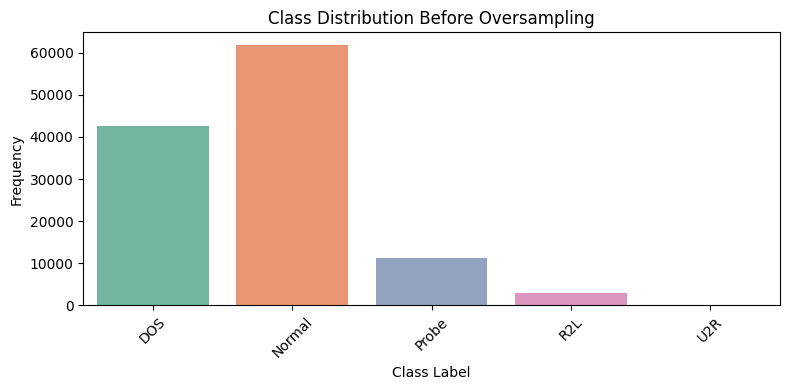

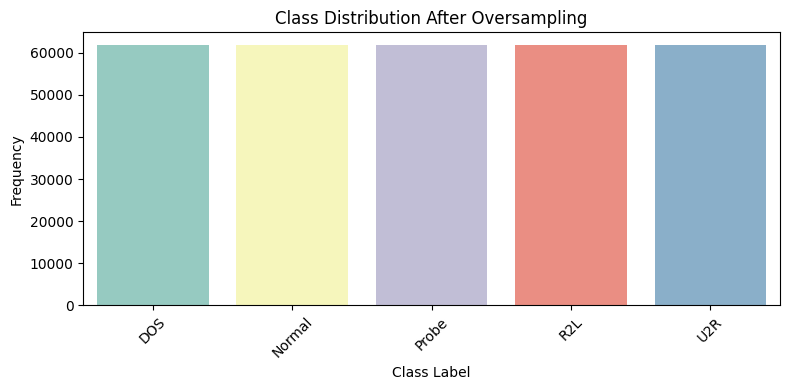

In [19]:
X = combined_data.drop("Class", axis=1).values
y = combined_data["Class"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

plt.figure(figsize=(8, 4))
sns.countplot(x=y_train, palette="Set2")
plt.title("Class Distribution Before Oversampling")
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

train_dataset = TensorDataset(torch.tensor(X_train_resampled, dtype=torch.float32),
                              torch.tensor(y_train_resampled, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_resampled, palette="Set3")
plt.title("Class Distribution After Oversampling")
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

feature_dim = X.shape[1]
num_classes = len(class_names)

invalid value encountered in less


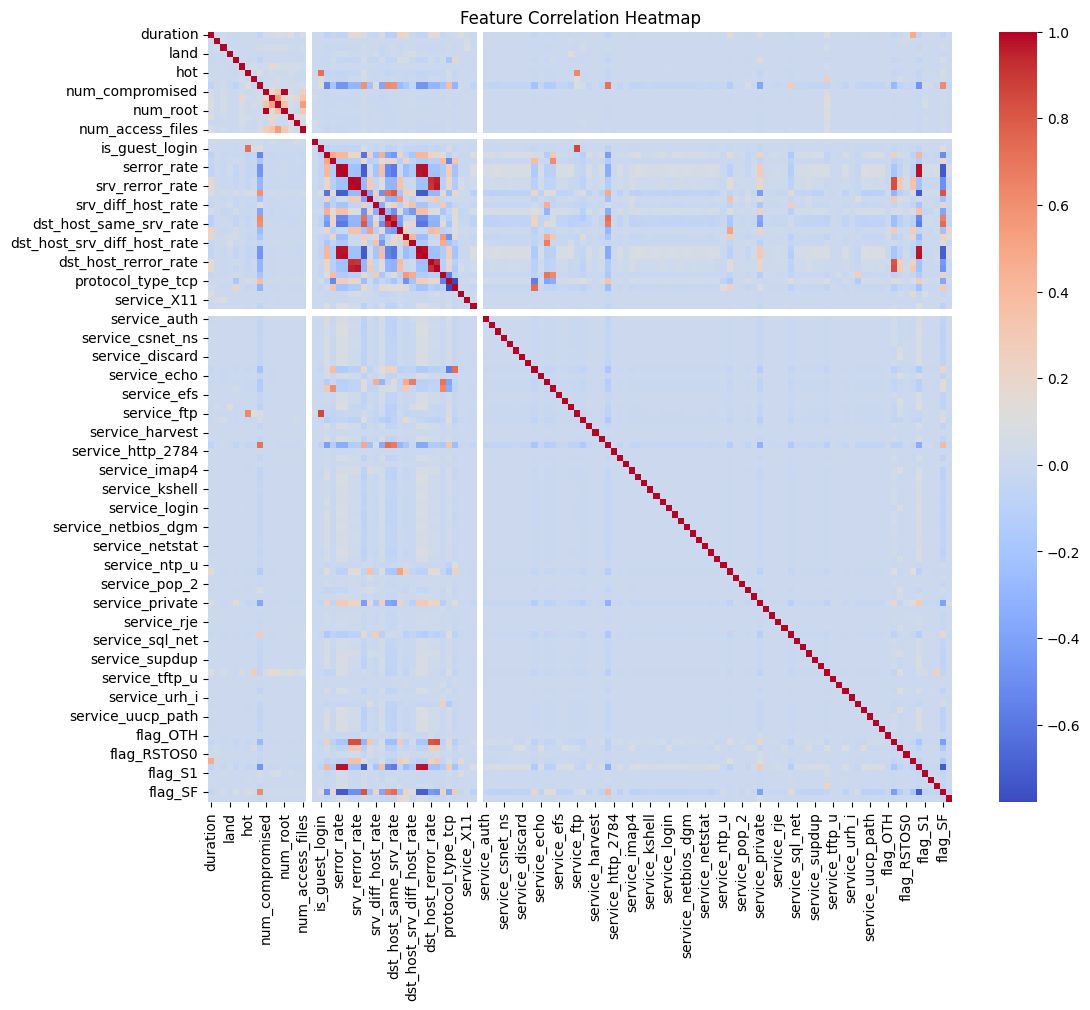

In [20]:
plt.figure(figsize=(12,10))
sns.heatmap(pd.DataFrame(X_train, columns=combined_data.columns[:-1]).corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [23]:
class CNN(nn.Module):
    def __init__(self, input_dim):
        super(CNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        return self.net(x)

In [24]:
class BiLSTM_CNN(nn.Module):
    def __init__(self, input_dim, lstm_hidden=64, cnn_out=64, num_classes=5):
        super(BiLSTM_CNN, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=lstm_hidden,
                            num_layers=1, batch_first=True, bidirectional=True)
        self.cnn = nn.Conv1d(in_channels=2 * lstm_hidden, out_channels=cnn_out,
                             kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(cnn_out, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = x.repeat(1, x.shape[2], 1)
        out, _ = self.lstm(x)
        out = out.permute(0, 2, 1)
        out = self.relu(self.cnn(out))
        out = self.global_pool(out).squeeze(-1)
        out = self.fc(out)
        return out

In [25]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, input_dim, cnn_out=64, lstm_hidden=64, num_classes=5):
        super(CNN_BiLSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, cnn_out, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(input_size=cnn_out, hidden_size=lstm_hidden,
                            num_layers=1, batch_first=True, bidirectional=True)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(2 * lstm_hidden, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out.permute(0, 2, 1)
        out = self.global_pool(out).squeeze(-1)
        out = self.fc(out)
        return out

In [26]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [27]:
def train_model(model, train_loader, test_loader, name, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss_history = []
    test_accuracy_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(train_loss)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                preds = torch.argmax(output, dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)
        accuracy = correct / total
        test_accuracy_history.append(accuracy)

        print(f"{name} Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Accuracy: {accuracy:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_history, label="Loss", linewidth=2)
    plt.plot(test_accuracy_history, label="Accuracy", linewidth=2)
    plt.title(f"{name} Training Performance", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            preds = torch.argmax(output, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(y_batch.numpy())

    print(f"\n{name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

In [28]:
def plot_confusion_matrix(model, test_loader, class_names, title):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            preds = torch.argmax(output, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(y_batch.numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {title}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Selected Features by PI:
 ['src_bytes', 'diff_srv_rate', 'count', 'wrong_fragment', 'dst_bytes', 'dst_host_same_src_port_rate', 'dst_host_rerror_rate', 'service_http', 'dst_host_count', 'num_failed_logins', 'service_private', 'duration', 'srv_count', 'dst_host_diff_srv_rate', 'dst_host_srv_count']


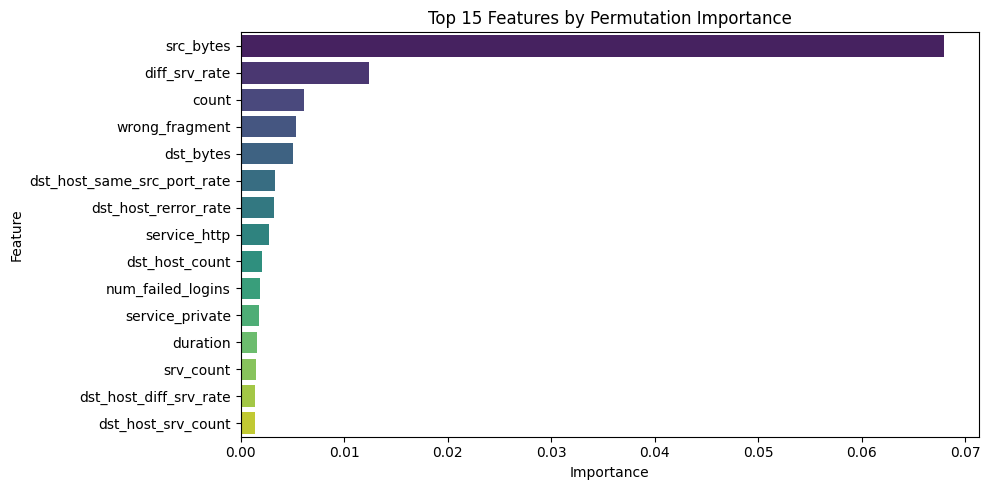

In [29]:
from sklearn.inspection import permutation_importance

xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42,
                              use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

pi_result = permutation_importance(xgb_model, X_train, y_train,
                                   n_repeats=10, random_state=42, n_jobs=-1)

top_indices = np.argsort(pi_result.importances_mean)[-15:][::-1]
selected_feature_names = [combined_data.columns[i] for i in top_indices]
print("Selected Features by PI:\n", selected_feature_names)

X_selected = X[:, top_indices]
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)

ros = RandomOverSampler(random_state=42)
X_train_resampled_sel, y_train_resampled_sel = ros.fit_resample(X_train_sel, y_train_sel)

train_dataset_sel = TensorDataset(torch.tensor(X_train_resampled_sel, dtype=torch.float32),
                                  torch.tensor(y_train_resampled_sel, dtype=torch.long))
test_dataset_sel = TensorDataset(torch.tensor(X_test_sel, dtype=torch.float32),
                                 torch.tensor(y_test_sel, dtype=torch.long))

train_loader_sel = DataLoader(train_dataset_sel, batch_size=64, shuffle=True)
test_loader_sel = DataLoader(test_dataset_sel, batch_size=64)

importances_df = pd.DataFrame({
    'Feature': combined_data.columns[top_indices],
    'Importance': pi_result.importances_mean[top_indices]
})

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importances_df, palette='viridis')
plt.title("Top 15 Features by Permutation Importance")
plt.tight_layout()
plt.show()

In [30]:
feature_dim_sel = 15

cnn_model = CNN(feature_dim_sel)
bilstm_cnn_model = BiLSTM_CNN(feature_dim_sel, num_classes=num_classes)
cnn_bilstm_model = CNN_BiLSTM(feature_dim_sel, num_classes=num_classes)
mlp_model = MLP(feature_dim_sel, num_classes=num_classes)

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CNN with PI Features Epoch 1/10 | Loss: 0.7940 | Accuracy: 0.8000
CNN with PI Features Epoch 2/10 | Loss: 0.5942 | Accuracy: 0.8231
CNN with PI Features Epoch 3/10 | Loss: 0.5301 | Accuracy: 0.8407
CNN with PI Features Epoch 4/10 | Loss: 0.4931 | Accuracy: 0.8414
CNN with PI Features Epoch 5/10 | Loss: 0.4613 | Accuracy: 0.8568
CNN with PI Features Epoch 6/10 | Loss: 0.4375 | Accuracy: 0.8465
CNN with PI Features Epoch 7/10 | Loss: 0.4184 | Accuracy: 0.8565
CNN with PI Features Epoch 8/10 | Loss: 0.4036 | Accuracy: 0.8689
CNN with PI Features Epoch 9/10 | Loss: 0.3916 | Accuracy: 0.8799
CNN with PI Features Epoch 10/10 | Loss: 0.3813 | Accuracy: 0.8826


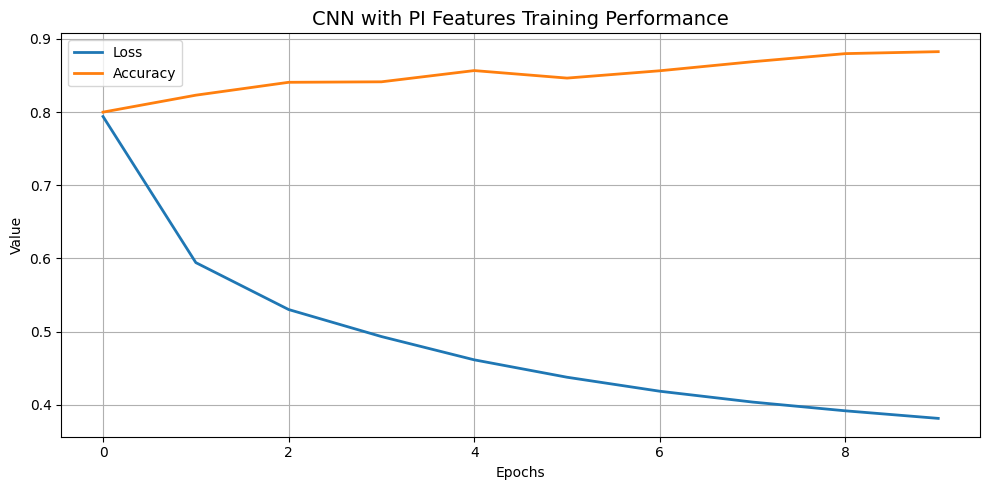


CNN with PI Features Classification Report:
              precision    recall  f1-score   support

         DOS       0.97      0.95      0.96     10678
      Normal       0.97      0.83      0.90     15447
       Probe       0.85      0.92      0.88      2815
         R2L       0.30      0.83      0.44       740
         U2R       0.02      0.88      0.04        24

    accuracy                           0.88     29704
   macro avg       0.62      0.88      0.65     29704
weighted avg       0.94      0.88      0.91     29704



In [32]:
train_model(cnn_model, train_loader_sel, test_loader_sel, name="CNN with PI Features", epochs=10)

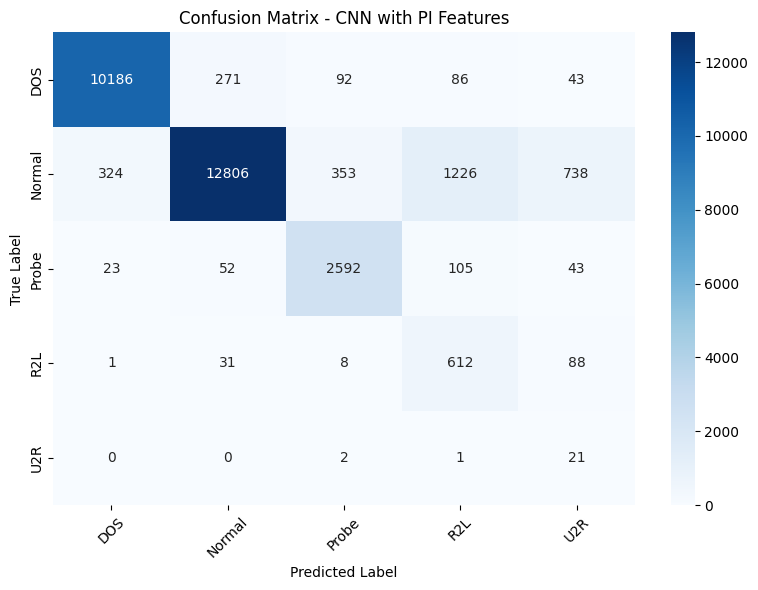

In [33]:
plot_confusion_matrix(cnn_model, test_loader_sel, class_names, "CNN with PI Features")

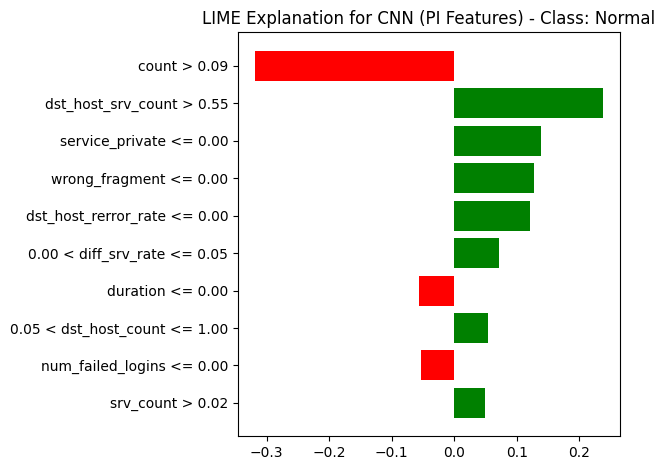

Top important features for this instance:
count > 0.09: -0.3183
dst_host_srv_count > 0.55: 0.2376
service_private <= 0.00: 0.1383
wrong_fragment <= 0.00: 0.1273
dst_host_rerror_rate <= 0.00: 0.1213
0.00 < diff_srv_rate <= 0.05: 0.0716
duration <= 0.00: -0.0571
0.05 < dst_host_count <= 1.00: 0.0543
num_failed_logins <= 0.00: -0.0524
srv_count > 0.02: 0.0498


In [34]:
cnn_model.eval()

def predict_fn(input_numpy):
    cnn_model.eval()
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = cnn_model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled_sel,
    feature_names=selected_feature_names,
    class_names=class_names,
    mode='classification'
)

sample_idx = 25
sample = X_test_sel[sample_idx]
sample_label = y_test_sel[sample_idx]

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)

fig = exp.as_pyplot_figure(label=sample_label)
plt.title(f"LIME Explanation for CNN (PI Features) - Class: {class_names[sample_label]}")
plt.tight_layout()
plt.show()

print("Top important features for this instance:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

CNN-BiLSTM with PI Features Epoch 1/10 | Loss: 0.5043 | Accuracy: 0.8886
CNN-BiLSTM with PI Features Epoch 2/10 | Loss: 0.2812 | Accuracy: 0.9076
CNN-BiLSTM with PI Features Epoch 3/10 | Loss: 0.2153 | Accuracy: 0.9364
CNN-BiLSTM with PI Features Epoch 4/10 | Loss: 0.1787 | Accuracy: 0.9369
CNN-BiLSTM with PI Features Epoch 5/10 | Loss: 0.1502 | Accuracy: 0.9464
CNN-BiLSTM with PI Features Epoch 6/10 | Loss: 0.1300 | Accuracy: 0.9539
CNN-BiLSTM with PI Features Epoch 7/10 | Loss: 0.1182 | Accuracy: 0.9484
CNN-BiLSTM with PI Features Epoch 8/10 | Loss: 0.1069 | Accuracy: 0.9524
CNN-BiLSTM with PI Features Epoch 9/10 | Loss: 0.0977 | Accuracy: 0.9567
CNN-BiLSTM with PI Features Epoch 10/10 | Loss: 0.0896 | Accuracy: 0.9554


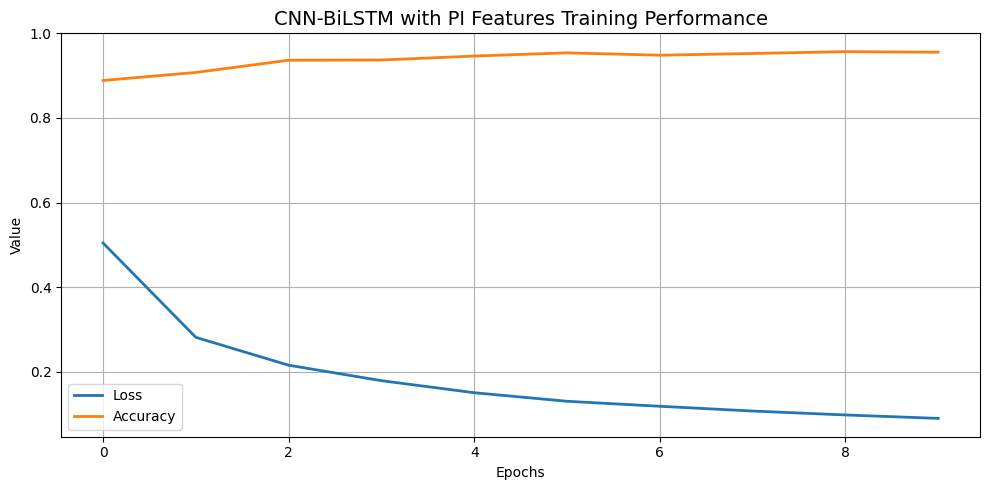


CNN-BiLSTM with PI Features Classification Report:
              precision    recall  f1-score   support

         DOS       0.98      0.99      0.99     10678
      Normal       0.99      0.93      0.96     15447
       Probe       0.95      0.96      0.96      2815
         R2L       0.51      0.93      0.66       740
         U2R       0.05      0.54      0.09        24

    accuracy                           0.96     29704
   macro avg       0.70      0.87      0.73     29704
weighted avg       0.97      0.96      0.96     29704



In [35]:
train_model(cnn_bilstm_model, train_loader_sel, test_loader_sel, name="CNN-BiLSTM with PI Features", epochs=10)

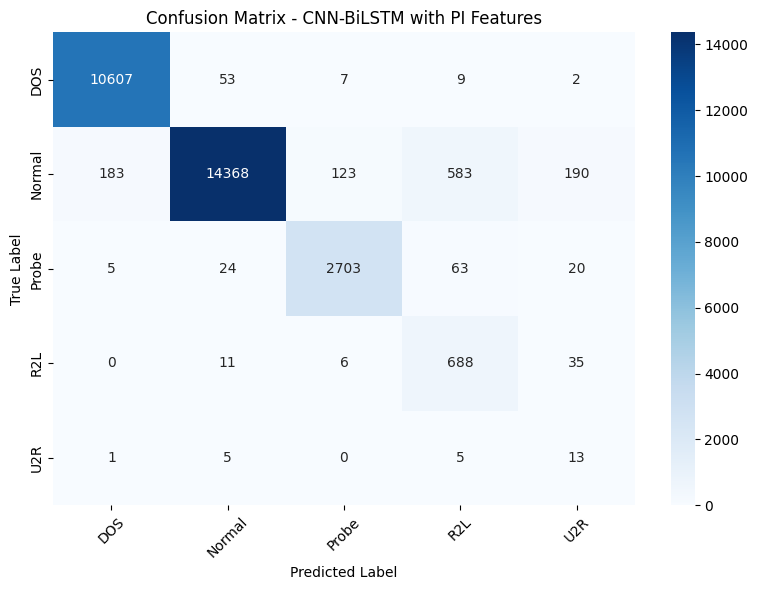

In [36]:
plot_confusion_matrix(cnn_bilstm_model, test_loader_sel, class_names, "CNN-BiLSTM with PI Features")

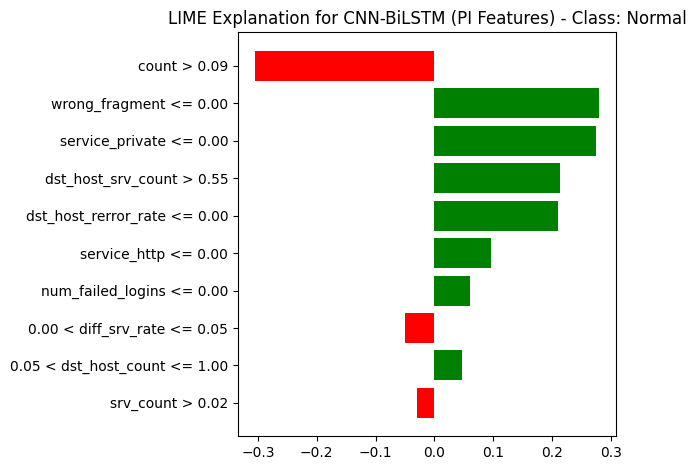

Top important features for this instance:
count > 0.09: -0.3046
wrong_fragment <= 0.00: 0.2802
service_private <= 0.00: 0.2747
dst_host_srv_count > 0.55: 0.2134
dst_host_rerror_rate <= 0.00: 0.2101
service_http <= 0.00: 0.0962
num_failed_logins <= 0.00: 0.0609
0.00 < diff_srv_rate <= 0.05: -0.0494
0.05 < dst_host_count <= 1.00: 0.0467
srv_count > 0.02: -0.0302


In [37]:
def predict_fn(input_numpy):
    cnn_bilstm_model.eval()
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = cnn_bilstm_model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled_sel,
    feature_names=selected_feature_names,
    class_names=class_names,
    mode="classification"
)

sample_idx = 25
sample = X_test_sel[sample_idx]
sample_label = y_test_sel[sample_idx]

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)
fig = exp.as_pyplot_figure(label=sample_label)
plt.title(f"LIME Explanation for CNN-BiLSTM (PI Features) - Class: {class_names[sample_label]}")
plt.tight_layout()
plt.show()

print("Top important features for this instance:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

MLP with PI Features Epoch 1/10 | Loss: 0.4530 | Accuracy: 0.8950
MLP with PI Features Epoch 2/10 | Loss: 0.3125 | Accuracy: 0.9146
MLP with PI Features Epoch 3/10 | Loss: 0.2649 | Accuracy: 0.9268
MLP with PI Features Epoch 4/10 | Loss: 0.2375 | Accuracy: 0.9205
MLP with PI Features Epoch 5/10 | Loss: 0.2192 | Accuracy: 0.9288
MLP with PI Features Epoch 6/10 | Loss: 0.2046 | Accuracy: 0.9335
MLP with PI Features Epoch 7/10 | Loss: 0.1925 | Accuracy: 0.9365
MLP with PI Features Epoch 8/10 | Loss: 0.1830 | Accuracy: 0.9412
MLP with PI Features Epoch 9/10 | Loss: 0.1735 | Accuracy: 0.9419
MLP with PI Features Epoch 10/10 | Loss: 0.1674 | Accuracy: 0.9436


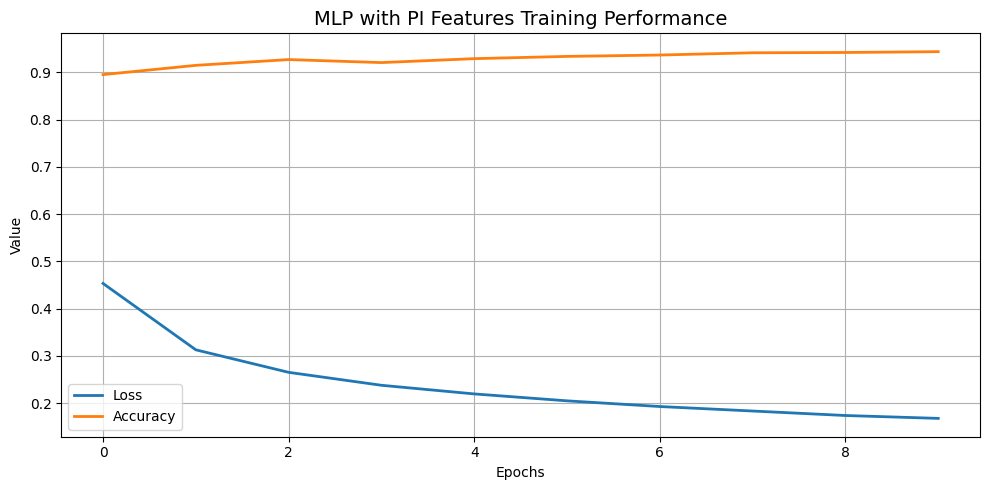


MLP with PI Features Classification Report:
              precision    recall  f1-score   support

         DOS       0.98      0.99      0.99     10678
      Normal       0.99      0.91      0.95     15447
       Probe       0.95      0.95      0.95      2815
         R2L       0.49      0.91      0.64       740
         U2R       0.03      0.83      0.07        24

    accuracy                           0.94     29704
   macro avg       0.69      0.92      0.72     29704
weighted avg       0.97      0.94      0.96     29704



In [38]:
train_model(mlp_model, train_loader_sel, test_loader_sel, name="MLP with PI Features", epochs=10)

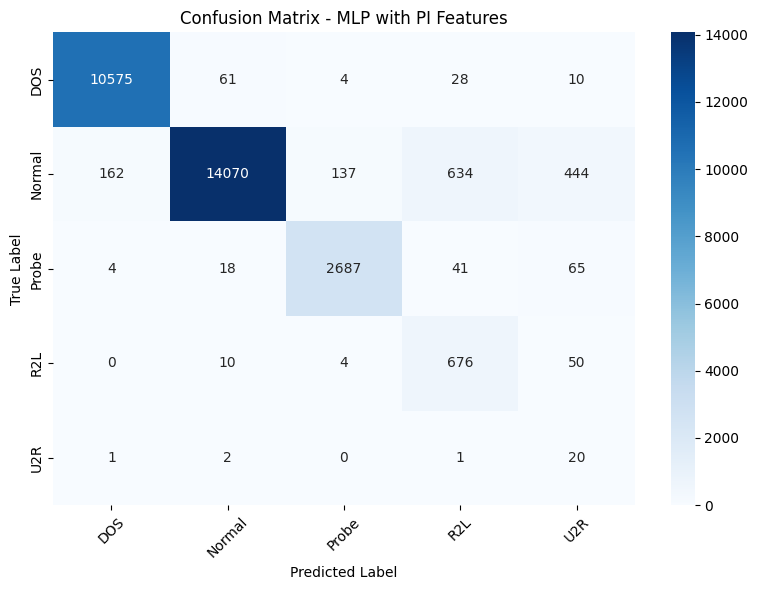

In [40]:
plot_confusion_matrix(mlp_model, test_loader_sel, class_names, "MLP with PI Features")

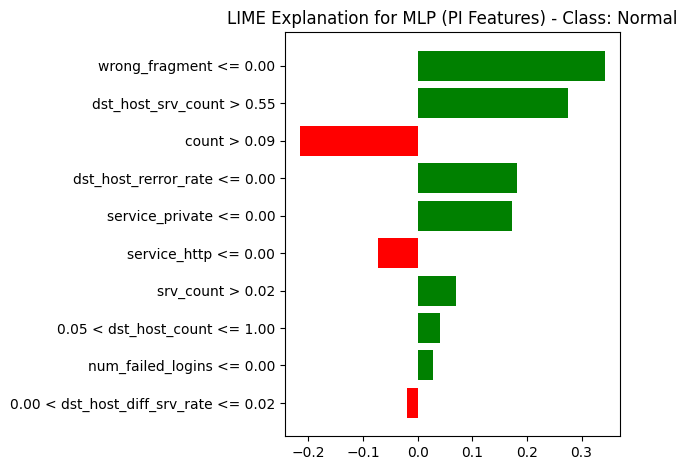

Top important features for this instance:
wrong_fragment <= 0.00: 0.3425
dst_host_srv_count > 0.55: 0.2755
count > 0.09: -0.2150
dst_host_rerror_rate <= 0.00: 0.1813
service_private <= 0.00: 0.1735
service_http <= 0.00: -0.0735
srv_count > 0.02: 0.0700
0.05 < dst_host_count <= 1.00: 0.0409
num_failed_logins <= 0.00: 0.0286
0.00 < dst_host_diff_srv_rate <= 0.02: -0.0203


In [41]:
mlp_model.eval()

def predict_fn(input_numpy):
    mlp_model.eval()
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = mlp_model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled_sel,
    feature_names=selected_feature_names,
    class_names=class_names,
    mode='classification'
)

sample_idx = 25
sample = X_test_sel[sample_idx]
sample_label = y_test_sel[sample_idx]

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)
fig = exp.as_pyplot_figure(label=sample_label)
plt.title(f"LIME Explanation for MLP (PI Features) - Class: {class_names[sample_label]}")
plt.tight_layout()
plt.show()

print("Top important features for this instance:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

In [42]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
model.fit(X_train_resampled_sel, y_train_resampled_sel)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [43]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_resampled_sel)
print(type(shap_values))

<class 'list'>


In [44]:
if isinstance(shap_values, list):
    print(len(shap_values))
    print(shap_values[0].shape)
else:
    print(shap_values.shape)

5
(308925, 15)


In [50]:
print("shap_values shape:", np.array(shap_values).shape)
print("len(selected_feature_names):", len(selected_feature_names))
print("mean_abs_shap shape:", mean_abs_shap.shape)


shap_values shape: (5, 308925, 15)
len(selected_feature_names): 15
mean_abs_shap shape: (308925,)


In [51]:
abs_shap = np.abs(shap_values)
mean_abs_shap = abs_shap.mean(axis=(0, 1))  # ← درست
sorted_idx = np.argsort(mean_abs_shap)[::-1]

print("Top features based on SHAP value:\n")
for i in sorted_idx[:10]:
    print(f"{selected_feature_names[i]}: {mean_abs_shap[i]:.4f}")

Top features based on SHAP value:

src_bytes: 1.8454
dst_bytes: 1.3141
count: 0.6896
dst_host_same_src_port_rate: 0.5731
dst_host_srv_count: 0.5679
duration: 0.4529
dst_host_diff_srv_rate: 0.4400
dst_host_count: 0.4189
dst_host_rerror_rate: 0.3953
srv_count: 0.3839


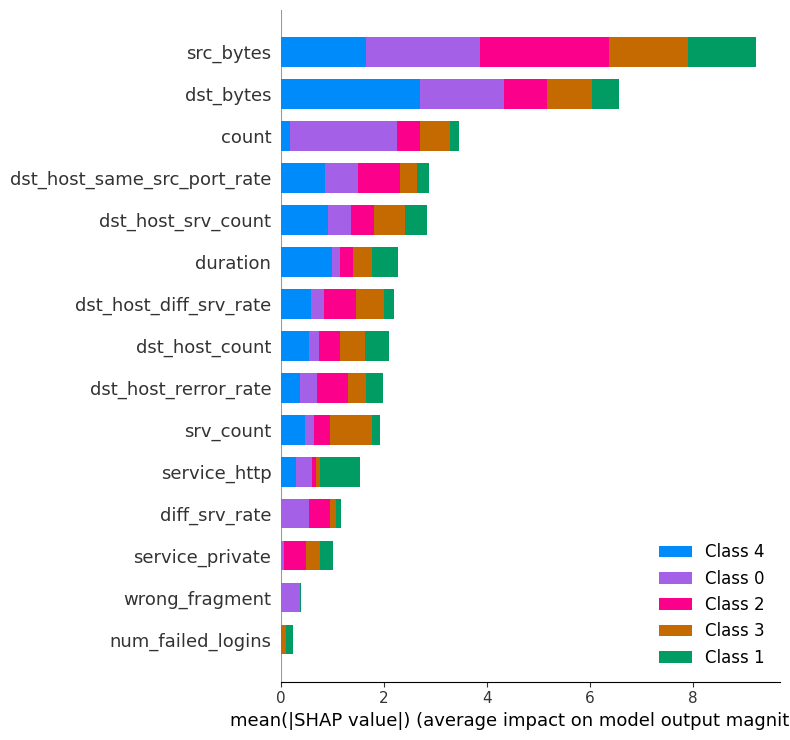

In [46]:
shap.summary_plot(shap_values, X_train_sel, feature_names=selected_feature_names, plot_type="bar", max_display=15)

In [53]:
top_features = [selected_feature_names[i] for i in sorted_idx[:40]]
feature_indices = [selected_feature_names.index(f) for f in top_features]

In [54]:
X_train_selected = X_train_resampled_sel[:, feature_indices]
X_test_selected = X_test_sel[:, feature_indices]

In [55]:
train_dataset_selected = TensorDataset(torch.tensor(X_train_selected, dtype=torch.float32),
                                       torch.tensor(y_train_resampled_sel, dtype=torch.long))
test_dataset_selected = TensorDataset(torch.tensor(X_test_selected, dtype=torch.float32),
                                      torch.tensor(y_test, dtype=torch.long))

train_loader_selected = DataLoader(train_dataset_selected, batch_size=64, shuffle=True)
test_loader_selected = DataLoader(test_dataset_selected, batch_size=64)

In [56]:
feature_dim_selected = len(feature_indices)

BiLSTM-CNN with top Features Epoch 1/10 | Loss: 0.3903 | Accuracy: 0.9026
BiLSTM-CNN with top Features Epoch 2/10 | Loss: 0.2452 | Accuracy: 0.9352
BiLSTM-CNN with top Features Epoch 3/10 | Loss: 0.1955 | Accuracy: 0.9276
BiLSTM-CNN with top Features Epoch 4/10 | Loss: 0.1710 | Accuracy: 0.9392
BiLSTM-CNN with top Features Epoch 5/10 | Loss: 0.1542 | Accuracy: 0.9446
BiLSTM-CNN with top Features Epoch 6/10 | Loss: 0.1396 | Accuracy: 0.9443
BiLSTM-CNN with top Features Epoch 7/10 | Loss: 0.1256 | Accuracy: 0.9543
BiLSTM-CNN with top Features Epoch 8/10 | Loss: 0.1198 | Accuracy: 0.9550
BiLSTM-CNN with top Features Epoch 9/10 | Loss: 0.1103 | Accuracy: 0.9592
BiLSTM-CNN with top Features Epoch 10/10 | Loss: 0.1049 | Accuracy: 0.9567


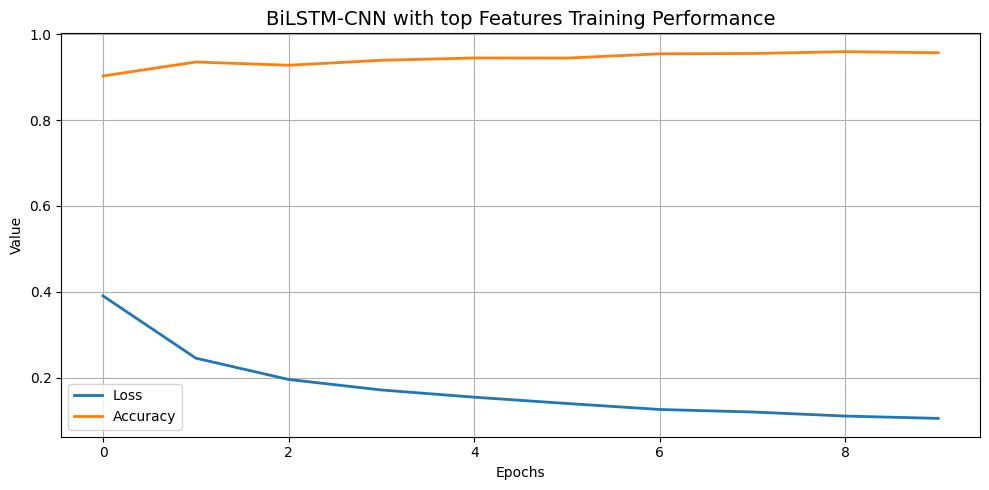


BiLSTM-CNN with top Features Classification Report:
              precision    recall  f1-score   support

         DOS       0.97      0.99      0.98     10678
      Normal       1.00      0.93      0.96     15447
       Probe       0.95      0.96      0.96      2815
         R2L       0.56      0.93      0.70       740
         U2R       0.06      0.75      0.12        24

    accuracy                           0.96     29704
   macro avg       0.71      0.91      0.74     29704
weighted avg       0.97      0.96      0.96     29704



In [57]:
model_selected = BiLSTM_CNN(input_dim=feature_dim_selected, num_classes=num_classes).to(device)
train_model(model_selected, train_loader_selected, test_loader_selected, "BiLSTM-CNN with top Features", epochs=10)

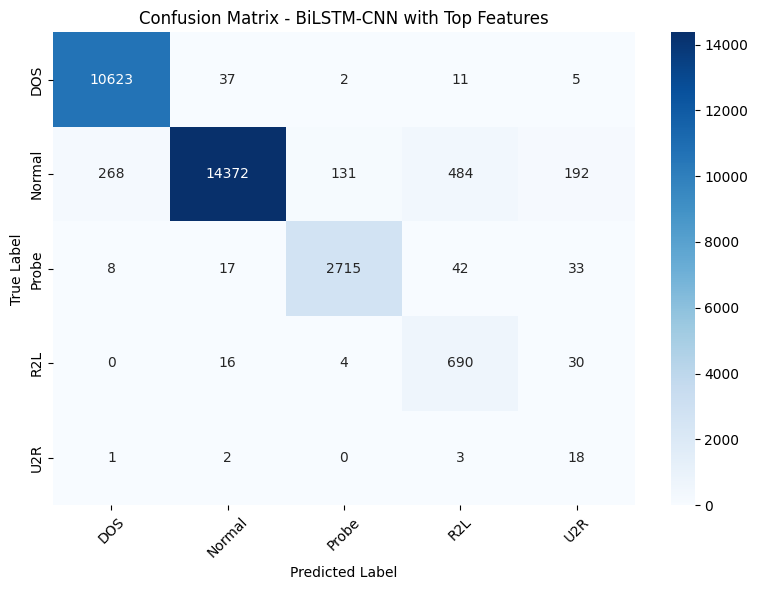

In [58]:
plot_confusion_matrix(model_selected, test_loader_selected, class_names, "BiLSTM-CNN with Top Features")

In [59]:
model_selected.eval()
def predict_fn(input_numpy):
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        output = model_selected(input_tensor)
        probs = torch.softmax(output, dim=1)
    return probs.cpu().numpy()

In [60]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_selected,
    feature_names=top_features,
    class_names=class_names,
    mode="classification"
)

sample_idx = 25
sample = X_test_selected[sample_idx]
sample_label = y_test[sample_idx]

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)

In [61]:
important_features = exp.as_list()
print("Top important features for this instance:")
for feature, weight in important_features:
    print(f"{feature}: {weight:.4f}")

Top important features for this instance:
wrong_fragment <= 0.00: 0.3507
count > 0.09: -0.2636
dst_host_srv_count > 0.55: 0.2357
dst_host_rerror_rate <= 0.00: 0.2022
duration <= 0.00: -0.1679
service_private <= 0.00: 0.1614
srv_count > 0.02: -0.0497
dst_host_same_src_port_rate <= 0.00: -0.0488
0.05 < dst_host_count <= 1.00: 0.0284
0.00 < diff_srv_rate <= 0.05: -0.0260


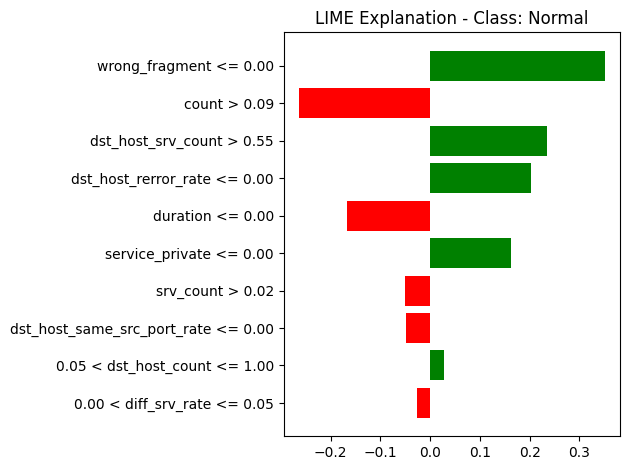

In [62]:
exp.as_pyplot_figure(label=sample_label)
plt.title(f"LIME Explanation - Class: {class_names[sample_label]}")
plt.tight_layout()
plt.show()

In [63]:
def get_model_outputs(model, loader):
    model.eval()
    y_true = []
    y_score = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            y_true.append(labels.cpu().numpy())
            y_score.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_score = np.concatenate(y_score)
    return y_true, y_score

In [64]:
def plot_roc_pr_curves(models_dict, class_names):
    plt.figure(figsize=(16, 6))

    # --- ROC Curve ---
    plt.subplot(1, 2, 1)
    for name, (model, loader) in models_dict.items():
        y_true, y_score = get_model_outputs(model, loader)
        y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title('ROC Curve', fontsize=14)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True)

    # --- PR Curve ---
    plt.subplot(1, 2, 2)
    for name, (model, loader) in models_dict.items():
        y_true, y_score = get_model_outputs(model, loader)
        y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
        precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
        ap_score = average_precision_score(y_bin, y_score, average="micro")
        plt.plot(recall, precision, label=f'{name} (AP = {ap_score:.2f})')

    plt.title('Precision-Recall Curve', fontsize=14)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

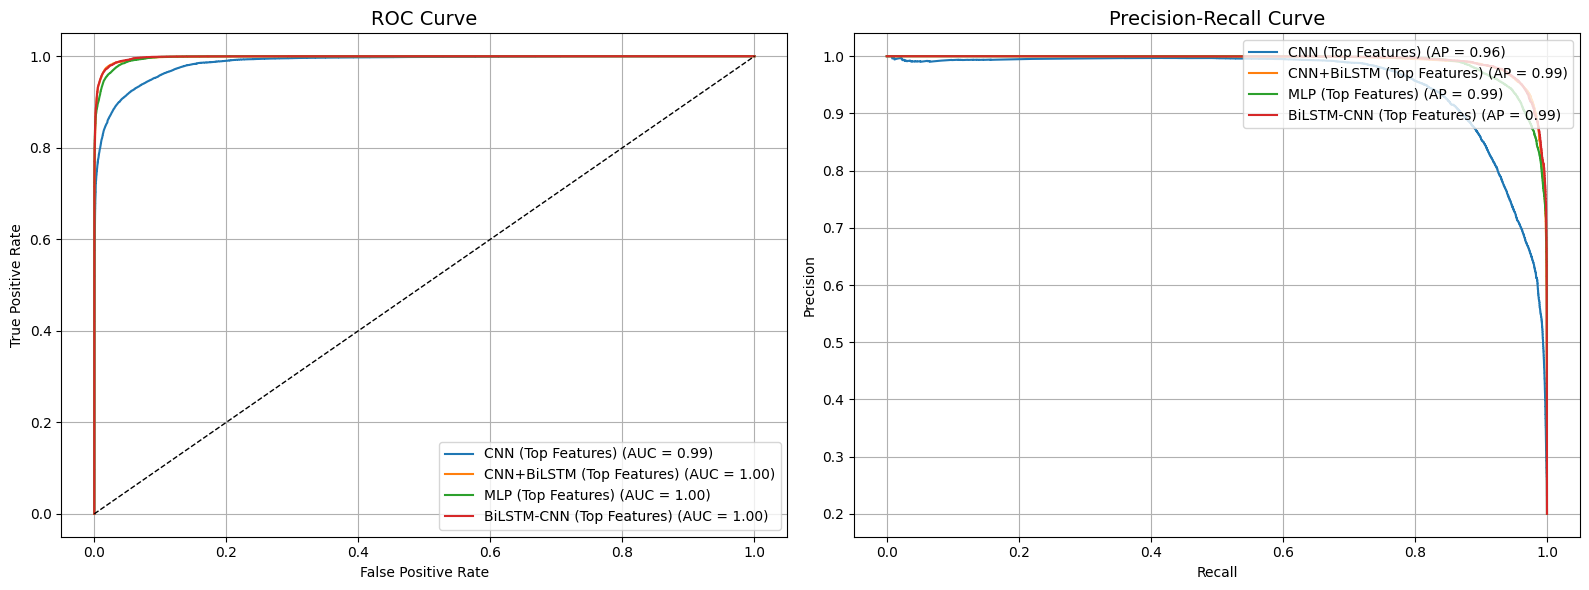

In [65]:
models_dict = {
    "CNN (Top Features)": (cnn_model, test_loader_sel),
    "CNN+BiLSTM (Top Features)": (cnn_bilstm_model, test_loader_sel),
    "MLP (Top Features)": (mlp_model, test_loader_sel),
    "BiLSTM-CNN (Top Features)": (model_selected, test_loader_selected)
}

plot_roc_pr_curves(models_dict, class_names)

In [66]:
def evaluate_model_metrics(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            preds = torch.argmax(output, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(y_batch.numpy())

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1": f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

    return metrics

In [67]:
def plot_radar_chart(metrics_dict):
    categories = list(next(iter(metrics_dict.values())).keys())
    N = len(categories)

    df = pd.DataFrame(metrics_dict).T
    df = df[categories]

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    for model_name, row in df.iterrows():
        values = row.tolist()
        values += values[:1]
        plt.polar(angles, values, label=model_name, linewidth=2)
        plt.fill(angles, values, alpha=0.1)

    plt.xticks(angles[:-1], categories)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
    plt.tight_layout()
    plt.show()

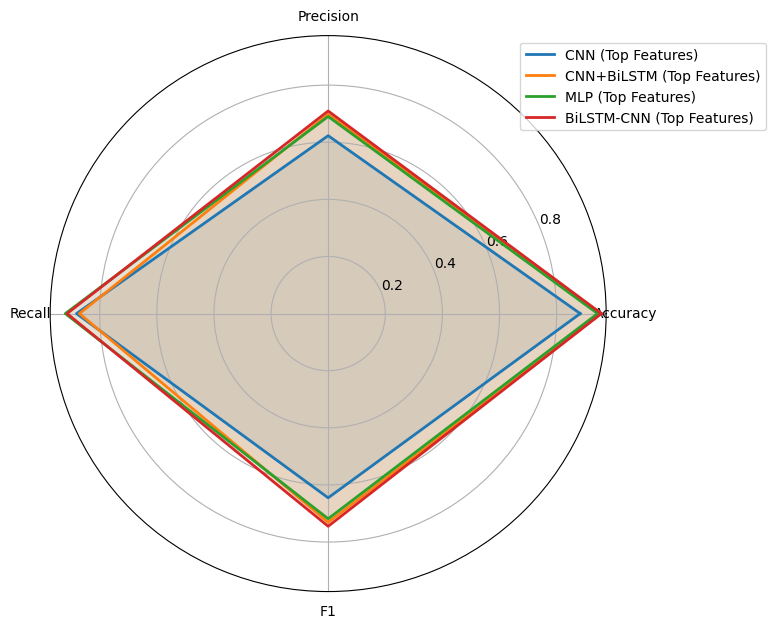

In [68]:
metrics = {
    "CNN (Top Features)": evaluate_model_metrics(cnn_model, test_loader_sel),
    "CNN+BiLSTM (Top Features)": evaluate_model_metrics(cnn_bilstm_model, test_loader_sel),
    "MLP (Top Features)": evaluate_model_metrics(mlp_model, test_loader_sel),
    "BiLSTM-CNN (Top Features)": evaluate_model_metrics(model_selected, test_loader_selected),
}

plot_radar_chart(metrics)

In [69]:
from sklearn.metrics import classification_report

def cross_validate_model(model_class, X, y, k=5, epochs=10, batch_size=64, model_name="Model", oversample=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    all_metrics = []
    all_reports = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n===== Fold {fold+1} / {k} =====")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        if oversample:
            ros = RandomOverSampler(random_state=42)
            X_train, y_train = ros.fit_resample(X_train, y_train)

        train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                      torch.tensor(y_train, dtype=torch.long))
        val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                    torch.tensor(y_val, dtype=torch.long))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        input_dim = X.shape[1]
        n_classes = len(np.unique(y))

        try:
            model = model_class(input_dim, num_classes=n_classes)
        except TypeError:
            try:
                model = model_class(input_dim, n_classes)
            except TypeError:
                model = model_class(n_classes)

        model.to(device)

        train_model(model, train_loader, val_loader, f"{model_name} Fold-{fold+1}", epochs=epochs)
        fold_metrics = evaluate_model_metrics(model, val_loader)

        # === Get predictions for classification report ===
        y_true, y_pred = [], []
        model.eval()
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                outputs = model(Xb)
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(yb.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        all_reports.append(pd.DataFrame(report_dict).T)

        print(f"Fold {fold+1} metrics: {fold_metrics}")
        all_metrics.append(fold_metrics)

    # ===== Compute aggregated metrics =====
    df_metrics = pd.DataFrame(all_metrics)
    mean_metrics = df_metrics.mean()
    std_metrics = df_metrics.std()

    print("\n===== Final Cross-Validation Results =====")
    print("Mean Metrics:\n", mean_metrics)
    print("Std Dev Metrics:\n", std_metrics)

    # ===== Compute average classification report =====
    avg_report = sum(all_reports) / len(all_reports)
    print("\n===== Mean Classification Report Across Folds =====")
    print(avg_report)

    return df_metrics, mean_metrics, std_metrics, avg_report


>>> Running CV for MLP with PI Features

===== Fold 1 / 5 =====
MLP with PI Features Fold-1 Epoch 1/20 | Loss: 0.1237 | Accuracy: 0.9705
MLP with PI Features Fold-1 Epoch 2/20 | Loss: 0.0673 | Accuracy: 0.9710
MLP with PI Features Fold-1 Epoch 3/20 | Loss: 0.0566 | Accuracy: 0.9761
MLP with PI Features Fold-1 Epoch 4/20 | Loss: 0.0512 | Accuracy: 0.9780
MLP with PI Features Fold-1 Epoch 5/20 | Loss: 0.0471 | Accuracy: 0.9816
MLP with PI Features Fold-1 Epoch 6/20 | Loss: 0.0453 | Accuracy: 0.9760
MLP with PI Features Fold-1 Epoch 7/20 | Loss: 0.0431 | Accuracy: 0.9779
MLP with PI Features Fold-1 Epoch 8/20 | Loss: 0.0412 | Accuracy: 0.9809
MLP with PI Features Fold-1 Epoch 9/20 | Loss: 0.0398 | Accuracy: 0.9793
MLP with PI Features Fold-1 Epoch 10/20 | Loss: 0.0390 | Accuracy: 0.9778
MLP with PI Features Fold-1 Epoch 11/20 | Loss: 0.0374 | Accuracy: 0.9798
MLP with PI Features Fold-1 Epoch 12/20 | Loss: 0.0368 | Accuracy: 0.9796
MLP with PI Features Fold-1 Epoch 13/20 | Loss: 0.0359 |

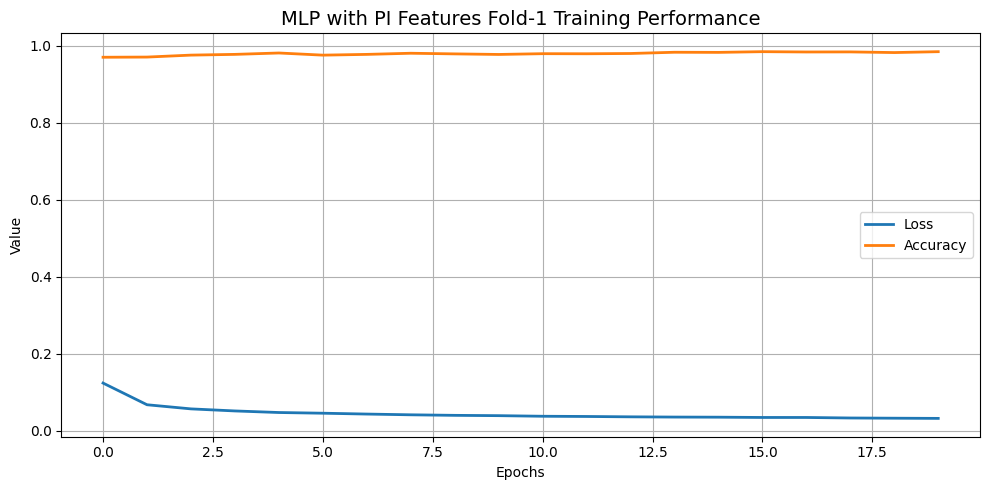


MLP with PI Features Fold-1 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.97      0.99     15447
       Probe       0.98      1.00      0.99      2815
         R2L       0.71      0.98      0.82       741
         U2R       0.31      0.67      0.42        24

    accuracy                           0.98     29704
   macro avg       0.80      0.92      0.84     29704
weighted avg       0.99      0.98      0.99     29704

Fold 1 metrics: {'Accuracy': 0.9849851871801778, 'Precision': 0.7975315931250304, 'Recall': 0.923501522137905, 'F1': 0.8427479688848731}

===== Fold 2 / 5 =====
MLP with PI Features Fold-2 Epoch 1/20 | Loss: 0.1359 | Accuracy: 0.9712
MLP with PI Features Fold-2 Epoch 2/20 | Loss: 0.0791 | Accuracy: 0.9774
MLP with PI Features Fold-2 Epoch 3/20 | Loss: 0.0664 | Accuracy: 0.9762
MLP with PI Features Fold-2 Epoch 4/20 | Loss: 0.0587 | Accuracy: 0.9807
MLP wi

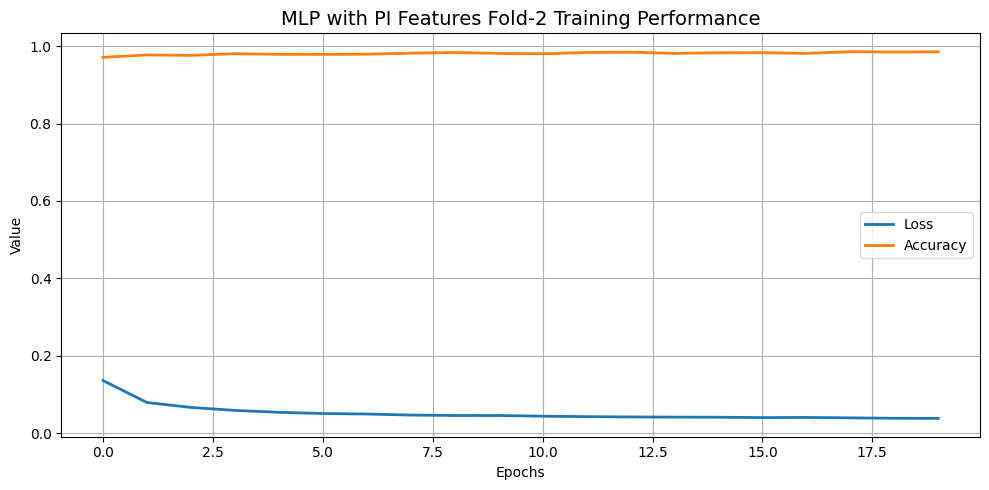


MLP with PI Features Fold-2 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.98      0.99     15447
       Probe       0.97      1.00      0.98      2816
         R2L       0.74      0.97      0.84       740
         U2R       0.26      0.71      0.38        24

    accuracy                           0.99     29704
   macro avg       0.79      0.93      0.84     29704
weighted avg       0.99      0.99      0.99     29704

Fold 2 metrics: {'Accuracy': 0.985523835173714, 'Precision': 0.7941913370943954, 'Recall': 0.9294817671764155, 'F1': 0.8381351814383203}

===== Fold 3 / 5 =====
MLP with PI Features Fold-3 Epoch 1/20 | Loss: 0.1387 | Accuracy: 0.9648
MLP with PI Features Fold-3 Epoch 2/20 | Loss: 0.0806 | Accuracy: 0.9772
MLP with PI Features Fold-3 Epoch 3/20 | Loss: 0.0680 | Accuracy: 0.9774
MLP with PI Features Fold-3 Epoch 4/20 | Loss: 0.0608 | Accuracy: 0.9749
MLP wi

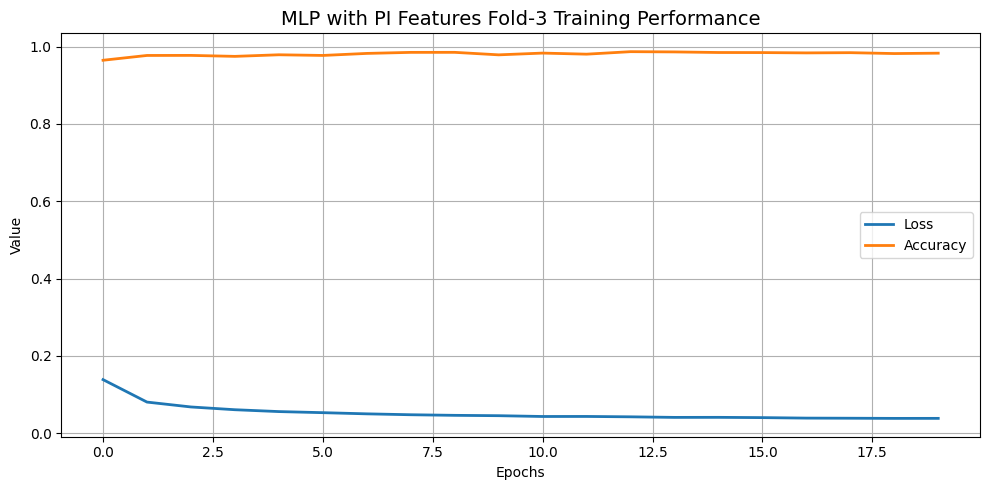


MLP with PI Features Fold-3 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10678
      Normal       1.00      0.97      0.98     15446
       Probe       0.98      1.00      0.99      2816
         R2L       0.67      0.98      0.79       740
         U2R       0.33      0.91      0.48        23

    accuracy                           0.98     29703
   macro avg       0.80      0.97      0.85     29703
weighted avg       0.99      0.98      0.98     29703

Fold 3 metrics: {'Accuracy': 0.9830993502339831, 'Precision': 0.7952286508468046, 'Recall': 0.971549153821365, 'F1': 0.8498627526085777}

===== Fold 4 / 5 =====
MLP with PI Features Fold-4 Epoch 1/20 | Loss: 0.1410 | Accuracy: 0.9685
MLP with PI Features Fold-4 Epoch 2/20 | Loss: 0.0804 | Accuracy: 0.9695
MLP with PI Features Fold-4 Epoch 3/20 | Loss: 0.0658 | Accuracy: 0.9731
MLP with PI Features Fold-4 Epoch 4/20 | Loss: 0.0593 | Accuracy: 0.9778
MLP wi

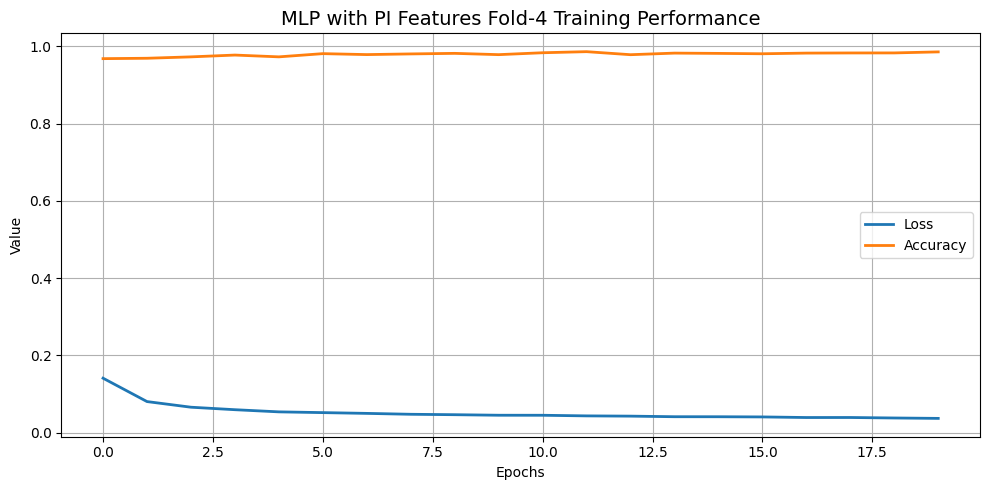


MLP with PI Features Fold-4 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10678
      Normal       1.00      0.98      0.99     15446
       Probe       0.97      1.00      0.98      2815
         R2L       0.77      0.94      0.85       740
         U2R       0.29      0.96      0.45        24

    accuracy                           0.99     29703
   macro avg       0.81      0.97      0.85     29703
weighted avg       0.99      0.99      0.99     29703

Fold 4 metrics: {'Accuracy': 0.986028347304986, 'Precision': 0.8051476181868665, 'Recall': 0.9746099766537262, 'F1': 0.8524540653280945}

===== Fold 5 / 5 =====
MLP with PI Features Fold-5 Epoch 1/20 | Loss: 0.1342 | Accuracy: 0.9627
MLP with PI Features Fold-5 Epoch 2/20 | Loss: 0.0769 | Accuracy: 0.9725
MLP with PI Features Fold-5 Epoch 3/20 | Loss: 0.0627 | Accuracy: 0.9733
MLP with PI Features Fold-5 Epoch 4/20 | Loss: 0.0549 | Accuracy: 0.9784
MLP wi

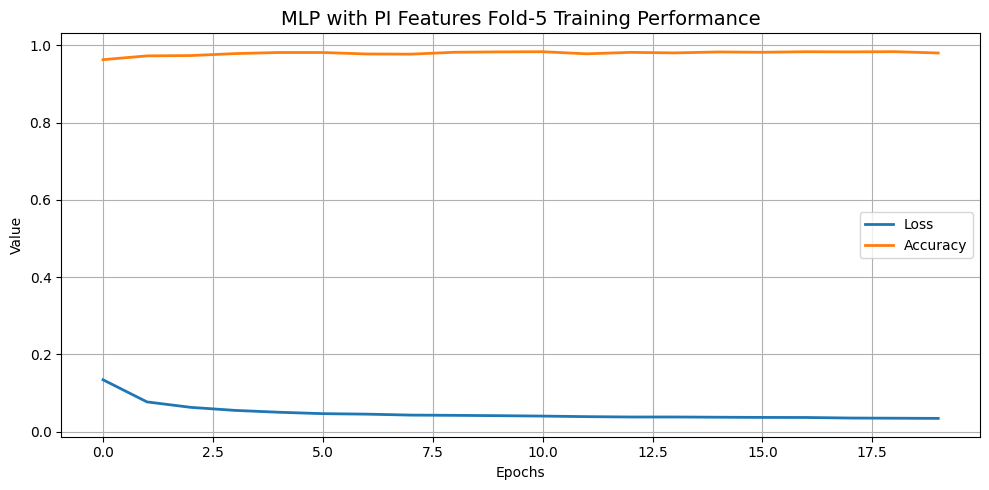


MLP with PI Features Fold-5 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.97      0.98     15446
       Probe       0.97      1.00      0.98      2815
         R2L       0.65      0.95      0.77       741
         U2R       0.21      0.62      0.32        24

    accuracy                           0.98     29703
   macro avg       0.76      0.91      0.81     29703
weighted avg       0.99      0.98      0.98     29703

Fold 5 metrics: {'Accuracy': 0.9799346867319799, 'Precision': 0.7649489213417258, 'Recall': 0.9078788337756232, 'F1': 0.8101078411706757}

===== Final Cross-Validation Results =====
Mean Metrics:
 Accuracy     0.983914
Precision    0.791410
Recall       0.941404
F1           0.838662
dtype: float64
Std Dev Metrics:
 Accuracy     0.002485
Precision    0.015401
Recall       0.029991
F1           0.016941
dtype: float64

===== Mean Classification Report Acro

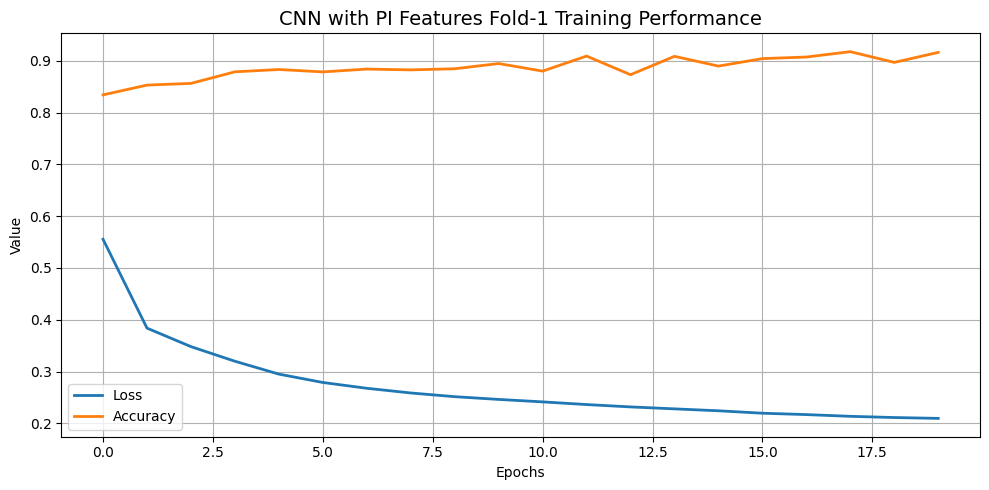


CNN with PI Features Fold-1 Classification Report:
              precision    recall  f1-score   support

         DOS       0.98      0.96      0.97     10677
      Normal       0.98      0.88      0.92     15447
       Probe       0.87      0.96      0.91      2815
         R2L       0.33      0.88      0.48       741
         U2R       0.08      0.75      0.14        24

    accuracy                           0.92     29704
   macro avg       0.65      0.89      0.69     29704
weighted avg       0.95      0.92      0.93     29704

Fold 1 metrics: {'Accuracy': 0.9161392405063291, 'Precision': 0.6459752753156134, 'Recall': 0.8869729146155448, 'F1': 0.6855753672141045}

===== Fold 2 / 5 =====
CNN with PI Features Fold-2 Epoch 1/20 | Loss: 0.6084 | Accuracy: 0.8130
CNN with PI Features Fold-2 Epoch 2/20 | Loss: 0.4475 | Accuracy: 0.7824
CNN with PI Features Fold-2 Epoch 3/20 | Loss: 0.3914 | Accuracy: 0.8748
CNN with PI Features Fold-2 Epoch 4/20 | Loss: 0.3526 | Accuracy: 0.8705
CNN w

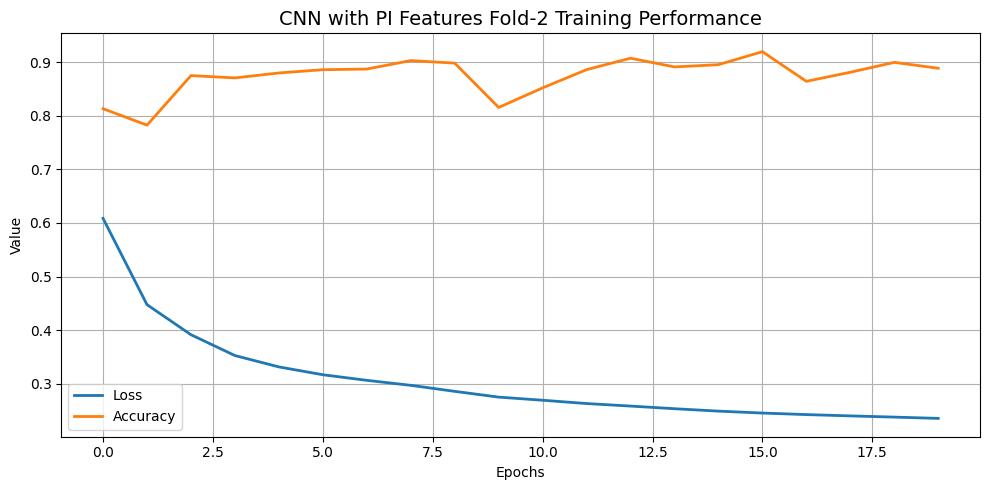


CNN with PI Features Fold-2 Classification Report:
              precision    recall  f1-score   support

         DOS       0.97      0.96      0.97     10677
      Normal       0.99      0.83      0.90     15447
       Probe       0.91      0.94      0.92      2816
         R2L       0.24      0.89      0.38       740
         U2R       0.03      0.67      0.06        24

    accuracy                           0.89     29704
   macro avg       0.63      0.86      0.65     29704
weighted avg       0.95      0.89      0.91     29704

Fold 2 metrics: {'Accuracy': 0.8885335308375977, 'Precision': 0.6274314383187123, 'Recall': 0.859314208915093, 'F1': 0.6476171475184996}

===== Fold 3 / 5 =====
CNN with PI Features Fold-3 Epoch 1/20 | Loss: 0.6300 | Accuracy: 0.7642
CNN with PI Features Fold-3 Epoch 2/20 | Loss: 0.4519 | Accuracy: 0.7895
CNN with PI Features Fold-3 Epoch 3/20 | Loss: 0.4111 | Accuracy: 0.8192
CNN with PI Features Fold-3 Epoch 4/20 | Loss: 0.3863 | Accuracy: 0.8540
CNN wi

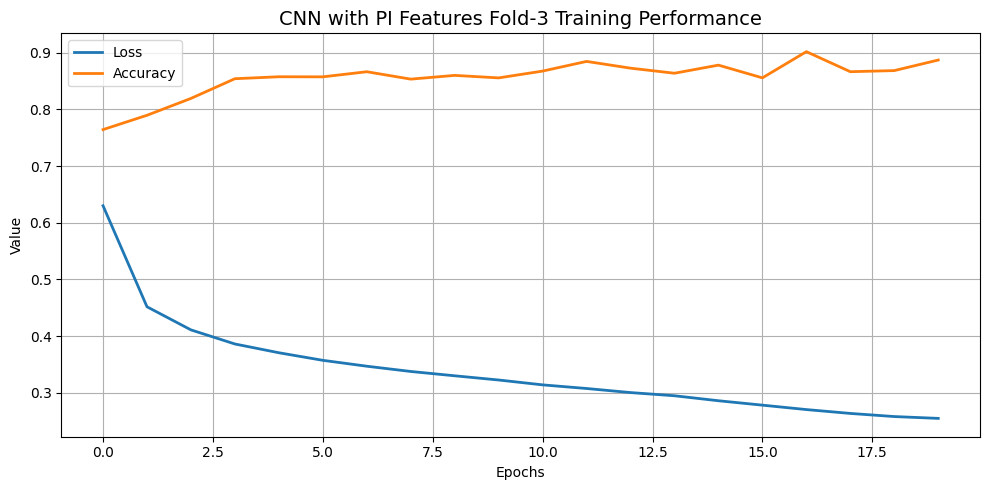


CNN with PI Features Fold-3 Classification Report:
              precision    recall  f1-score   support

         DOS       0.99      0.94      0.96     10678
      Normal       0.98      0.84      0.90     15446
       Probe       0.85      0.95      0.90      2816
         R2L       0.26      0.89      0.40       740
         U2R       0.03      0.91      0.07        23

    accuracy                           0.89     29703
   macro avg       0.62      0.91      0.65     29703
weighted avg       0.95      0.89      0.91     29703

Fold 3 metrics: {'Accuracy': 0.8868801131198869, 'Precision': 0.6217417136939934, 'Recall': 0.9076207725654214, 'F1': 0.646108010329337}

===== Fold 4 / 5 =====
CNN with PI Features Fold-4 Epoch 1/20 | Loss: 0.6467 | Accuracy: 0.8110
CNN with PI Features Fold-4 Epoch 2/20 | Loss: 0.4626 | Accuracy: 0.8158
CNN with PI Features Fold-4 Epoch 3/20 | Loss: 0.4060 | Accuracy: 0.8872
CNN with PI Features Fold-4 Epoch 4/20 | Loss: 0.3692 | Accuracy: 0.8291
CNN wi

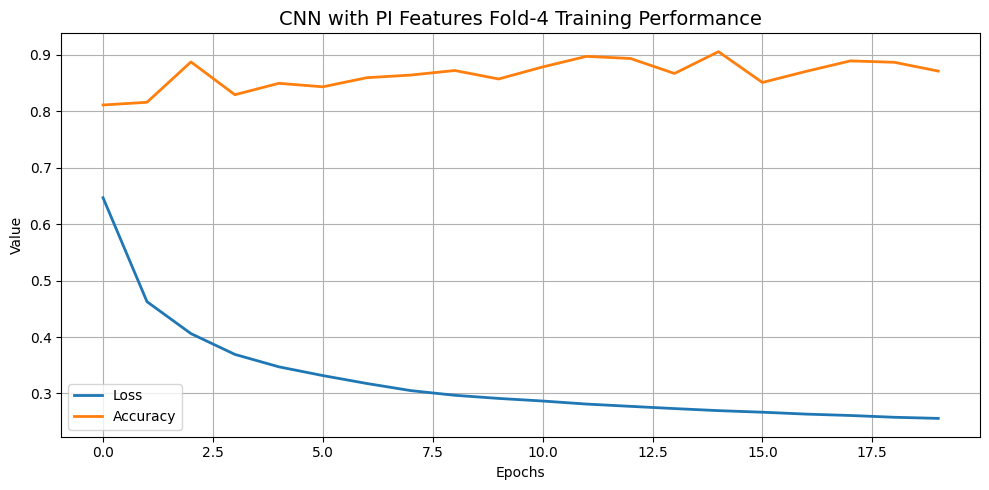


CNN with PI Features Fold-4 Classification Report:
              precision    recall  f1-score   support

         DOS       0.96      0.96      0.96     10678
      Normal       0.98      0.79      0.88     15446
       Probe       0.80      0.95      0.87      2815
         R2L       0.23      0.88      0.37       740
         U2R       0.05      0.83      0.09        24

    accuracy                           0.87     29703
   macro avg       0.61      0.88      0.63     29703
weighted avg       0.94      0.87      0.89     29703

Fold 4 metrics: {'Accuracy': 0.8710231289768711, 'Precision': 0.6053317013466476, 'Recall': 0.8847138155267181, 'F1': 0.6331196264721562}

===== Fold 5 / 5 =====
CNN with PI Features Fold-5 Epoch 1/20 | Loss: 0.5911 | Accuracy: 0.8194
CNN with PI Features Fold-5 Epoch 2/20 | Loss: 0.4235 | Accuracy: 0.8031
CNN with PI Features Fold-5 Epoch 3/20 | Loss: 0.3806 | Accuracy: 0.8690
CNN with PI Features Fold-5 Epoch 4/20 | Loss: 0.3504 | Accuracy: 0.8303
CNN w

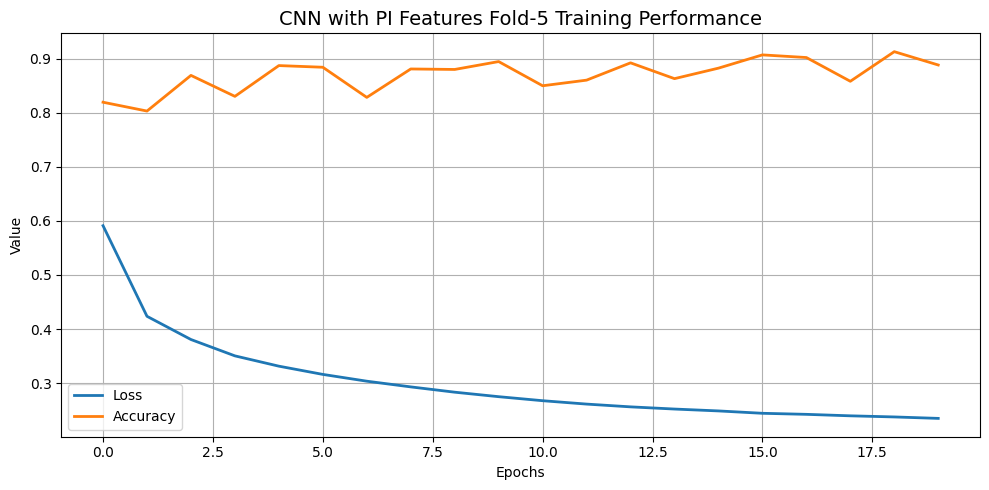


CNN with PI Features Fold-5 Classification Report:
              precision    recall  f1-score   support

         DOS       0.99      0.94      0.96     10677
      Normal       0.97      0.84      0.90     15446
       Probe       0.87      0.95      0.91      2815
         R2L       0.25      0.89      0.40       741
         U2R       0.04      0.75      0.08        24

    accuracy                           0.89     29703
   macro avg       0.62      0.87      0.65     29703
weighted avg       0.95      0.89      0.91     29703

Fold 5 metrics: {'Accuracy': 0.8882604450728883, 'Precision': 0.6236330705609711, 'Recall': 0.8736656404839387, 'F1': 0.6488600568893023}

===== Final Cross-Validation Results =====
Mean Metrics:
 Accuracy     0.890167
Precision    0.624823
Recall       0.882457
F1           0.652256
dtype: float64
Std Dev Metrics:
 Accuracy     0.016265
Precision    0.014535
Recall       0.017830
F1           0.019667
dtype: float64

===== Mean Classification Report Acro

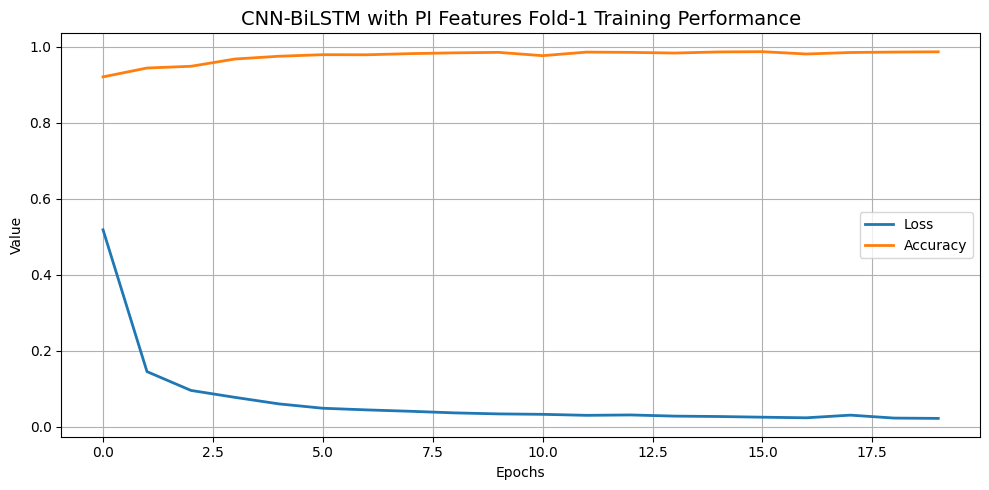


CNN-BiLSTM with PI Features Fold-1 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.98      0.99     15447
       Probe       0.97      0.99      0.98      2815
         R2L       0.76      0.98      0.86       741
         U2R       0.35      0.62      0.45        24

    accuracy                           0.99     29704
   macro avg       0.82      0.91      0.85     29704
weighted avg       0.99      0.99      0.99     29704

Fold 1 metrics: {'Accuracy': 0.9863991381632103, 'Precision': 0.8156234487968357, 'Recall': 0.9146305243555473, 'F1': 0.8545912255671866}

===== Fold 2 / 5 =====
CNN-BiLSTM with PI Features Fold-2 Epoch 1/20 | Loss: 0.6464 | Accuracy: 0.8915
CNN-BiLSTM with PI Features Fold-2 Epoch 2/20 | Loss: 0.1877 | Accuracy: 0.9426
CNN-BiLSTM with PI Features Fold-2 Epoch 3/20 | Loss: 0.1196 | Accuracy: 0.9572
CNN-BiLSTM with PI Features Fold-2 Epoch 4/20 | Lo

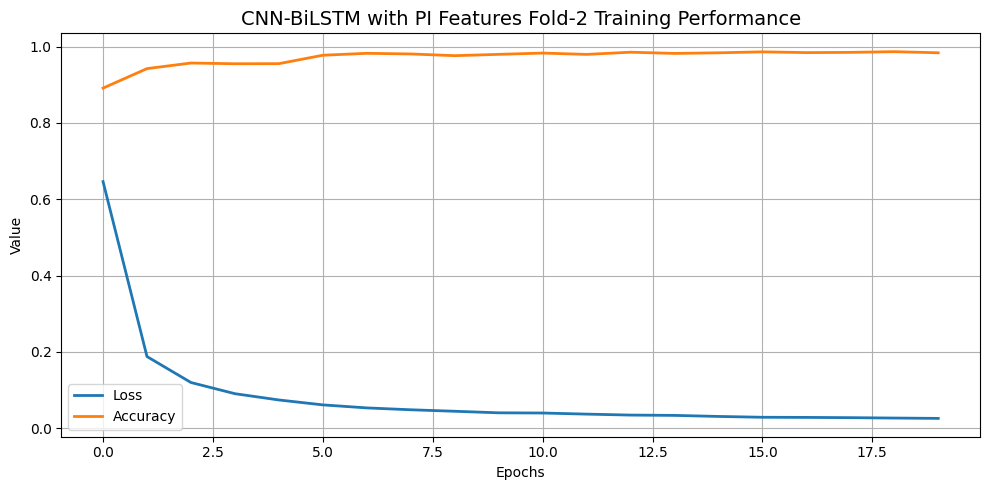


CNN-BiLSTM with PI Features Fold-2 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.97      0.99     15447
       Probe       0.97      1.00      0.98      2816
         R2L       0.72      0.96      0.83       740
         U2R       0.22      0.58      0.32        24

    accuracy                           0.98     29704
   macro avg       0.78      0.90      0.82     29704
weighted avg       0.99      0.98      0.99     29704

Fold 2 metrics: {'Accuracy': 0.9840762186910854, 'Precision': 0.7815635495530003, 'Recall': 0.9017257383841653, 'F1': 0.8217825064851025}

===== Fold 3 / 5 =====
CNN-BiLSTM with PI Features Fold-3 Epoch 1/20 | Loss: 0.6684 | Accuracy: 0.9199
CNN-BiLSTM with PI Features Fold-3 Epoch 2/20 | Loss: 0.1885 | Accuracy: 0.9381
CNN-BiLSTM with PI Features Fold-3 Epoch 3/20 | Loss: 0.1129 | Accuracy: 0.9621
CNN-BiLSTM with PI Features Fold-3 Epoch 4/20 | Lo

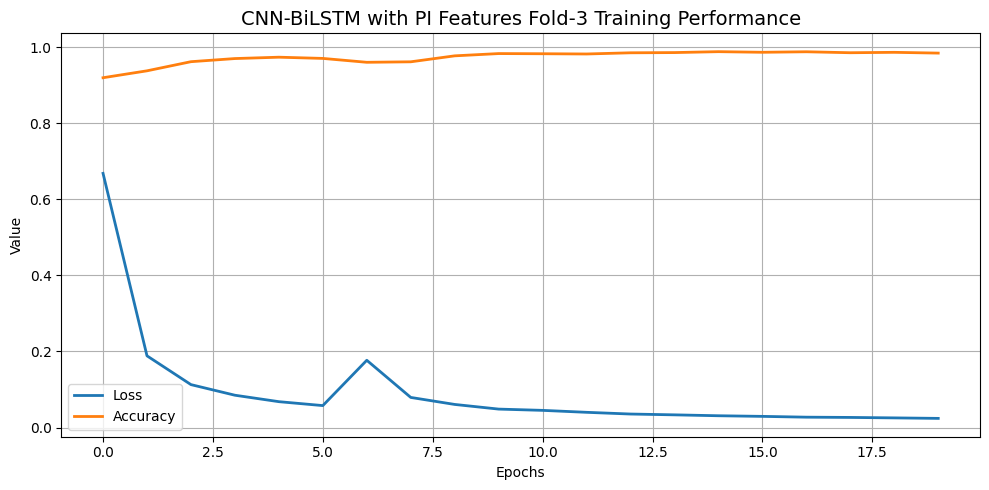


CNN-BiLSTM with PI Features Fold-3 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10678
      Normal       1.00      0.97      0.99     15446
       Probe       0.97      0.99      0.98      2816
         R2L       0.74      0.97      0.84       740
         U2R       0.30      0.91      0.46        23

    accuracy                           0.98     29703
   macro avg       0.80      0.97      0.85     29703
weighted avg       0.99      0.98      0.99     29703

Fold 3 metrics: {'Accuracy': 0.9847153486179847, 'Precision': 0.8016451783668683, 'Recall': 0.9694383328418917, 'F1': 0.8519844799121291}

===== Fold 4 / 5 =====
CNN-BiLSTM with PI Features Fold-4 Epoch 1/20 | Loss: 0.4853 | Accuracy: 0.9266
CNN-BiLSTM with PI Features Fold-4 Epoch 2/20 | Loss: 0.1560 | Accuracy: 0.9395
CNN-BiLSTM with PI Features Fold-4 Epoch 3/20 | Loss: 0.1135 | Accuracy: 0.9616
CNN-BiLSTM with PI Features Fold-4 Epoch 4/20 | Lo

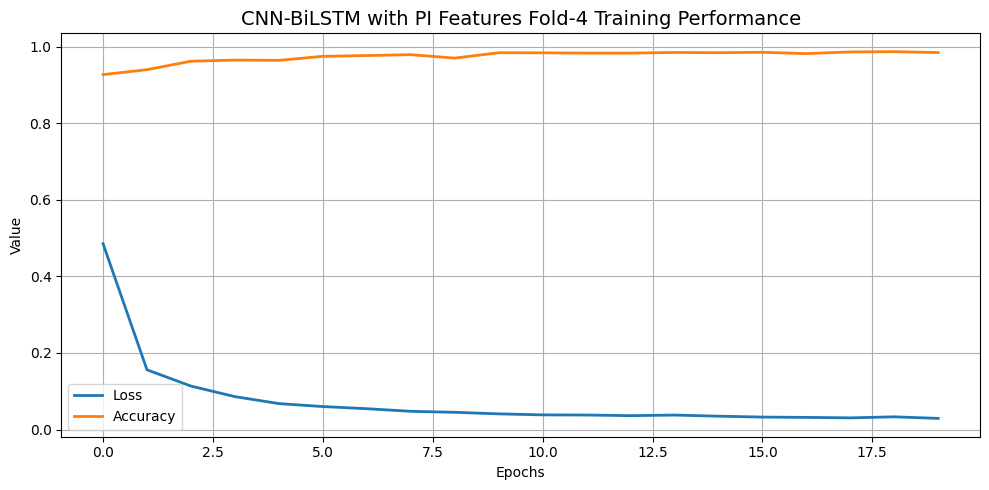


CNN-BiLSTM with PI Features Fold-4 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10678
      Normal       1.00      0.98      0.99     15446
       Probe       0.96      0.99      0.98      2815
         R2L       0.76      0.96      0.85       740
         U2R       0.30      0.88      0.44        24

    accuracy                           0.98     29703
   macro avg       0.80      0.96      0.85     29703
weighted avg       0.99      0.98      0.99     29703

Fold 4 metrics: {'Accuracy': 0.9841766824899841, 'Precision': 0.8024176139040857, 'Recall': 0.9592364753576034, 'F1': 0.849959087916005}

===== Fold 5 / 5 =====
CNN-BiLSTM with PI Features Fold-5 Epoch 1/20 | Loss: 0.7678 | Accuracy: 0.9028
CNN-BiLSTM with PI Features Fold-5 Epoch 2/20 | Loss: 0.1808 | Accuracy: 0.9389
CNN-BiLSTM with PI Features Fold-5 Epoch 3/20 | Loss: 0.1137 | Accuracy: 0.9453
CNN-BiLSTM with PI Features Fold-5 Epoch 4/20 | Los

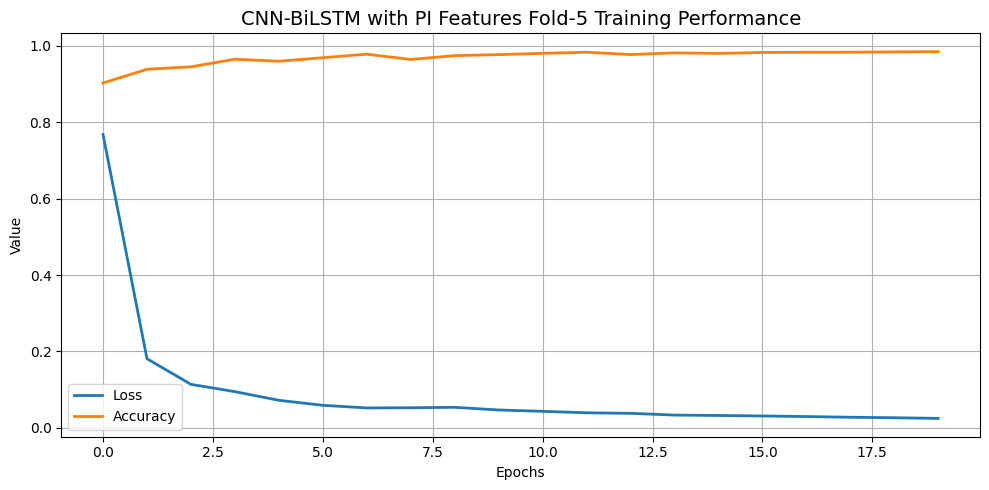


CNN-BiLSTM with PI Features Fold-5 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.98      0.99     15446
       Probe       0.97      0.98      0.98      2815
         R2L       0.77      0.96      0.86       741
         U2R       0.18      0.50      0.27        24

    accuracy                           0.98     29703
   macro avg       0.78      0.88      0.82     29703
weighted avg       0.99      0.98      0.99     29703

Fold 5 metrics: {'Accuracy': 0.9848836817829849, 'Precision': 0.7832139387471224, 'Recall': 0.8842235482321174, 'F1': 0.8167528384005092}

===== Final Cross-Validation Results =====
Mean Metrics:
 Accuracy     0.984850
Precision    0.796893
Recall       0.925851
F1           0.839014
dtype: float64
Std Dev Metrics:
 Accuracy     0.000932
Precision    0.014370
Recall       0.036930
F1           0.018188
dtype: float64

===== Mean Classification Repo

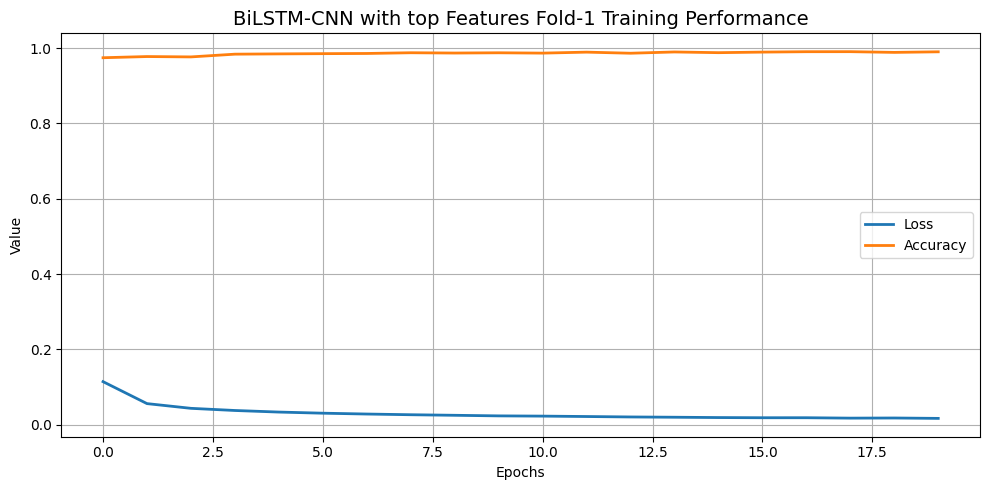


BiLSTM-CNN with top Features Fold-1 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.98      0.99     15447
       Probe       0.98      0.99      0.99      2815
         R2L       0.82      0.98      0.89       741
         U2R       0.35      0.62      0.45        24

    accuracy                           0.99     29704
   macro avg       0.83      0.92      0.86     29704
weighted avg       0.99      0.99      0.99     29704

Fold 1 metrics: {'Accuracy': 0.9901360086183679, 'Precision': 0.8296468444335096, 'Recall': 0.9156928619898395, 'F1': 0.8634855884890597}

===== Fold 2 / 5 =====
BiLSTM-CNN with top Features Fold-2 Epoch 1/20 | Loss: 0.1226 | Accuracy: 0.9664
BiLSTM-CNN with top Features Fold-2 Epoch 2/20 | Loss: 0.0660 | Accuracy: 0.9771
BiLSTM-CNN with top Features Fold-2 Epoch 3/20 | Loss: 0.0518 | Accuracy: 0.9790
BiLSTM-CNN with top Features Fold-2 Epoch 4/20

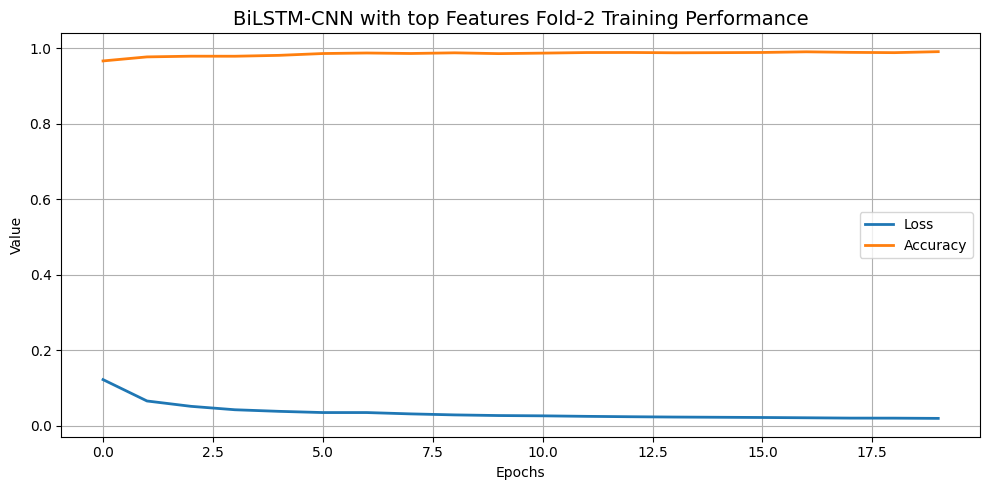


BiLSTM-CNN with top Features Fold-2 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.99      0.99     15447
       Probe       0.98      0.99      0.99      2816
         R2L       0.84      0.97      0.90       740
         U2R       0.36      0.67      0.46        24

    accuracy                           0.99     29704
   macro avg       0.84      0.92      0.87     29704
weighted avg       0.99      0.99      0.99     29704

Fold 2 metrics: {'Accuracy': 0.9909776461082682, 'Precision': 0.8358167204567751, 'Recall': 0.9225875895072873, 'F1': 0.8688990738952327}

===== Fold 3 / 5 =====
BiLSTM-CNN with top Features Fold-3 Epoch 1/20 | Loss: 0.1251 | Accuracy: 0.9697
BiLSTM-CNN with top Features Fold-3 Epoch 2/20 | Loss: 0.0687 | Accuracy: 0.9763
BiLSTM-CNN with top Features Fold-3 Epoch 3/20 | Loss: 0.0541 | Accuracy: 0.9816
BiLSTM-CNN with top Features Fold-3 Epoch 4/20

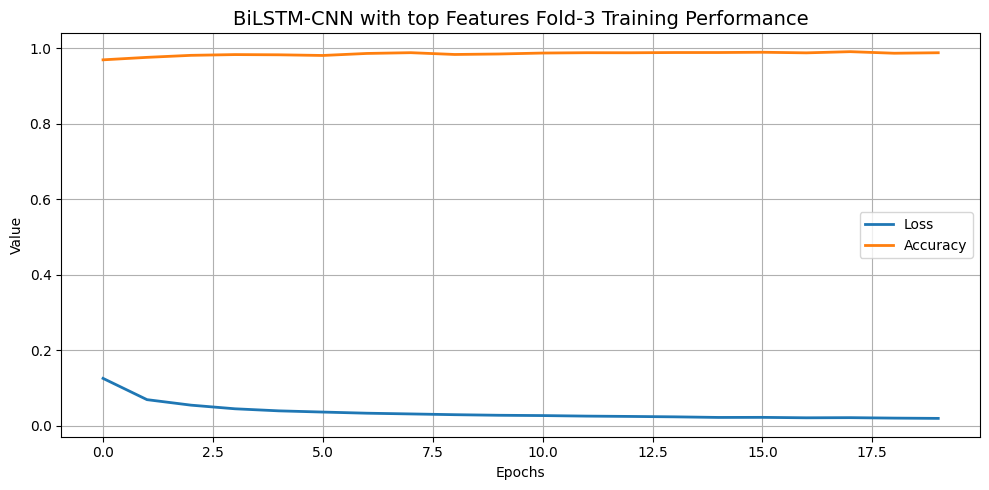


BiLSTM-CNN with top Features Fold-3 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10678
      Normal       1.00      0.98      0.99     15446
       Probe       0.98      0.99      0.98      2816
         R2L       0.79      0.98      0.87       740
         U2R       0.54      0.83      0.66        23

    accuracy                           0.99     29703
   macro avg       0.86      0.96      0.90     29703
weighted avg       0.99      0.99      0.99     29703

Fold 3 metrics: {'Accuracy': 0.9884860115139885, 'Precision': 0.8606094858818146, 'Recall': 0.9553111882693022, 'F1': 0.9000761670399106}

===== Fold 4 / 5 =====
BiLSTM-CNN with top Features Fold-4 Epoch 1/20 | Loss: 0.1289 | Accuracy: 0.9667
BiLSTM-CNN with top Features Fold-4 Epoch 2/20 | Loss: 0.0656 | Accuracy: 0.9755
BiLSTM-CNN with top Features Fold-4 Epoch 3/20 | Loss: 0.0497 | Accuracy: 0.9751
BiLSTM-CNN with top Features Fold-4 Epoch 4/20

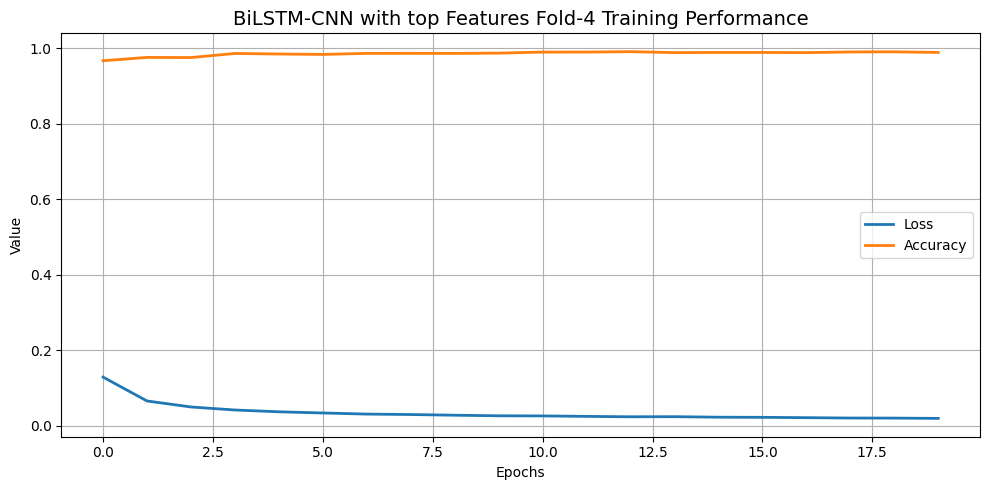


BiLSTM-CNN with top Features Fold-4 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10678
      Normal       1.00      0.98      0.99     15446
       Probe       0.99      0.99      0.99      2815
         R2L       0.77      0.97      0.86       740
         U2R       0.49      0.83      0.62        24

    accuracy                           0.99     29703
   macro avg       0.85      0.96      0.89     29703
weighted avg       0.99      0.99      0.99     29703

Fold 4 metrics: {'Accuracy': 0.9886206780459886, 'Precision': 0.8470701758065491, 'Recall': 0.9558056421504002, 'F1': 0.88996500511843}

===== Fold 5 / 5 =====
BiLSTM-CNN with top Features Fold-5 Epoch 1/20 | Loss: 0.1192 | Accuracy: 0.9692
BiLSTM-CNN with top Features Fold-5 Epoch 2/20 | Loss: 0.0630 | Accuracy: 0.9707
BiLSTM-CNN with top Features Fold-5 Epoch 3/20 | Loss: 0.0462 | Accuracy: 0.9746
BiLSTM-CNN with top Features Fold-5 Epoch 4/20 |

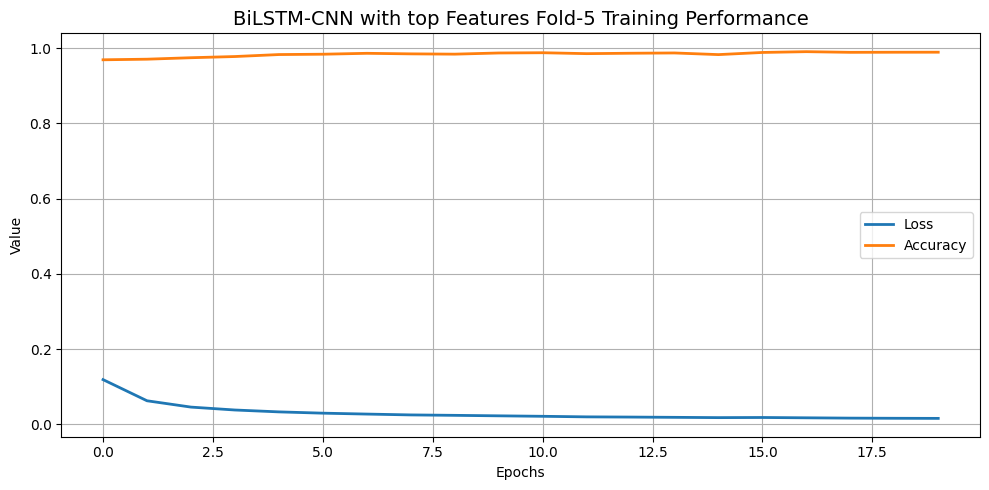


BiLSTM-CNN with top Features Fold-5 Classification Report:
              precision    recall  f1-score   support

         DOS       1.00      1.00      1.00     10677
      Normal       1.00      0.98      0.99     15446
       Probe       0.99      0.99      0.99      2815
         R2L       0.81      0.96      0.88       741
         U2R       0.41      0.62      0.49        24

    accuracy                           0.99     29703
   macro avg       0.84      0.91      0.87     29703
weighted avg       0.99      0.99      0.99     29703

Fold 5 metrics: {'Accuracy': 0.9893276773389893, 'Precision': 0.8383958692226754, 'Recall': 0.9124374008129529, 'F1': 0.8693221891125363}

===== Final Cross-Validation Results =====
Mean Metrics:
 Accuracy     0.989510
Precision    0.842308
Recall       0.932367
F1           0.878350
dtype: float64
Std Dev Metrics:
 Accuracy     0.001051
Precision    0.011993
Recall       0.021486
F1           0.015801
dtype: float64

===== Mean Classification Rep

In [70]:
if __name__ == "__main__":
    models_to_run = {
        "MLP with PI Features": MLP,
        "CNN with PI Features": CNN,
        "CNN-BiLSTM with PI Features": CNN_BiLSTM,
        "BiLSTM-CNN with top Features": BiLSTM_CNN
    }

    results = {}
    reports = {}

    for name, cls in models_to_run.items():
        print(f"\n>>> Running CV for {name}")
        df_metrics, mean_metrics, std_metrics, avg_report = cross_validate_model(
            cls, X, y, k=5, epochs=20, batch_size=32, model_name=name, oversample=True
        )
        results[name] = (df_metrics, mean_metrics, std_metrics)
        reports[name] = avg_report

    # ===== Summary of mean metrics =====
    summary = {name: mean for name, (_, mean, _) in results.items()}
    summary_df = pd.DataFrame(summary).T
    print("\n=== Summary of mean CV metrics ===")
    print(summary_df)

    # ===== Summary of mean classification reports =====
    for name, report in reports.items():
        print(f"\n=== Mean Classification Report for {name} ===")
        print(report)

    summary_df.to_csv("cv_summary_metrics.csv", index=True)
    for name, report in reports.items():
        report.to_csv(f"classification_report_mean_{name}.csv")